In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns
import os
import matplotlib.dates as mdates

In [58]:
# saving year indexed manifests and predictions

manifest_path = {}
manifest_path["2023"] = "../../MothSheets_photoManifest_2023.csv" 
all_manifests = {}
all_manifests["2023"] = pd.read_csv(manifest_path["2023"])


preds_path = {}
preds_path["2023"] = "../../Results/InferencePipeline/predictions_2023.csv"
all_preds = {}
all_preds["2023"] = pd.read_csv(preds_path["2023"])

In [83]:
LOCATIONS = ["WS1","WS4", "WS5", "WS6low", "WS6up"]

#input global parameters

YEAR = "2023"
CURRENT_LOC = "WS1"
binedges = [-3,1,3,5,8]

bin_specs = [
    {
        "count_col": "count_(-3.001, 1.0]",
        "bm_col": "bm_(-3.001, 1.0]",
        "label": "0.125 - 2 (cm²)",
        "color": "blue"
    },
    {
        "count_col": "count_(1.0, 3.0]",
        "bm_col": "bm_(1.0, 3.0]",
        "label": "2 - 8 (cm²)",
        "color": "orange"
    },
    {
        "count_col": "count_(3.0, 5.0]",
        "bm_col": "bm_(3.0, 5.0]",
        "label": "8 - 32 (cm²)",
        "color": "purple"
    },
    {
        "count_col": "count_(5.0, 8.0]",
        "bm_col": "bm_(5.0, 8.0]",
        "label": "32 - 216 (cm²)",
        "color": "skyblue"
    },
    {
        "count_col": "total",
        "bm_col": "bm_total",
        "label": "All Sizes",
        "color": "black"
    }
]

In [98]:
def retrieve_dataframes(YEAR, CURRENT_LOC):
    #retrieve manifest
    manifest =  all_manifests[YEAR][all_manifests[YEAR]["site"] == CURRENT_LOC]

    #retrive predictions
    preds = all_preds[YEAR][all_preds[YEAR]["site"] == CURRENT_LOC]
    return manifest, preds


def normalise_dataframes(manifest, preds):
    def pad_filename(name):
        parts = str(name).split("_") # expected format: year_site_date_time_camera.JPG , e.g. 2023_WS1_0611_5_WSCT4258.JPG
        if len(parts) >= 5:
            parts[3] = str(parts[3]).zfill(4)
        return "_".join(parts)

    manifest["fileName_old"] = manifest["fileName"]
    manifest["fileName"] = manifest["fileName"].apply(pad_filename)
    return manifest, preds


def merge_and_add_cols(manifest, preds):
    merged = preds.merge(manifest, on="fileName", how="left",suffixes=("_pred", "_manifest"))
    # add columns to merged sheet for trend analysis
    merged["size_log2"] = np.log2(merged["size"])
    merged["timebin"] = merged["dateTime_excel"].apply(lambda x: x.split(" ")[1].split(":")[0])
    merged = merged.sort_values(
        by='night.mmdd',
        key=lambda s: s.astype(str).str[-4:] + s.astype(str).str[-7:-4] + s.astype(str).str[-6:-4]
    )
    merged["size_bin"] = pd.cut(merged['size_log2'], bins=binedges, right=True, include_lowest=True)
    return merged


def build_hist(series):
    data = np.array(series)
    plt.figure(figsize=(15,5))

    plt.hist(data, bins=100)
    plt.xlabel("size_in_cm")
    plt.ylabel("frequency")
    plt.title("Spread of Moth Sizes cm for 2023")
    return


def plot_size_hist(merged_df):
    plt.figure(figsize=(20,5))
    data = np.array(merged_df["size_log2"])
    plt.hist(data,bins = binedges, edgecolor="black", color="maroon", alpha=.6)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.xlabel("Size in cms^2, log2 Scale")
    plt.ylabel("Count")
    plt.title("Distribution for Insect Sizes")


def aggregate_by_image(merged_df):
    img_aggregate = (pd.get_dummies(merged_df["size_bin"], prefix="count")
         .join(merged_df[["fileName", "night.mmdd", "dateTime_excel", "timebin"]])
         .groupby(["fileName", "night.mmdd", "dateTime_excel", "timebin"], as_index=False)
         .sum())
    return img_aggregate


def aggregate_by_night(img_aggregate):
    # BY NIGHT MAXIMUM COUNT
    bin_cols = [c for c in img_aggregate.columns if c.startswith("count_")]
    night_aggregate = (
        img_aggregate.groupby("night.mmdd", as_index=False)[bin_cols]
        .max()
    )
    cols =["count_(-3.001, 1.0]","count_(1.0, 3.0]", "count_(3.0, 5.0]", "count_(5.0, 8.0]"]
    night_aggregate["total"] = night_aggregate[cols].sum(axis=1)

    night_aggregate["bm_(-3.001, 1.0]"] = night_aggregate["count_(-3.001, 1.0]"]*3
    night_aggregate["bm_(1.0, 3.0]"] = night_aggregate["count_(1.0, 3.0]"]*57
    night_aggregate["bm_(3.0, 5.0]"] = night_aggregate["count_(3.0, 5.0]"]*279
    night_aggregate["bm_(5.0, 8.0]"] = night_aggregate["count_(5.0, 8.0]"]*418
    cols_bm =["bm_(-3.001, 1.0]","bm_(1.0, 3.0]", "bm_(3.0, 5.0]", "bm_(5.0, 8.0]"]
    night_aggregate["bm_total"] = night_aggregate[cols_bm].sum(axis=1)
    
    return night_aggregate   

def plot_it(night_aggregate):
    # -----------------------------
    # style
    # -----------------------------
    sns.set_theme(
        style="white",
        context="paper",
        rc={
            "axes.spines.top": False,
            "axes.spines.right": False
        }
    )

    # -----------------------------
    # data prep
    # -----------------------------
    df = night_aggregate.copy()

    # if night.mmdd is like 611, 620, 705 ...
    df["night.mmdd"] = pd.to_datetime(
        "2023" + df["night.mmdd"].astype(str).str.zfill(4),
        format="%Y%m%d"
    )

    # -----------------------------
    # helper formatting
    # -----------------------------
    def format_date_axis(ax):
        locator = mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
        formatter = mdates.DateFormatter("%b %d")
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(90)
        ax.grid(False)

    # -----------------------------
    # 1) one figure per bin: count + biomass side by side
    # -----------------------------
    for spec in bin_specs:
        cols = ["night.mmdd", spec["count_col"], spec["bm_col"]]
        d = df[cols].dropna().sort_values("night.mmdd").copy()

        if d.empty:
            print(f"Skipping {spec['label']} : no data")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(8.2, 2.8), dpi=300, sharex=True)

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["count_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=axes[0]
        )
        axes[0].set_title(spec["label"])
        axes[0].set_xlabel("Date")
        axes[0].set_ylabel("Count")
        format_date_axis(axes[0])

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["bm_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=axes[1]
        )
        axes[1].set_title(spec["label"])
        axes[1].set_xlabel("Date")
        axes[1].set_ylabel("Body Mass (mg)")
        format_date_axis(axes[1])

        fig.suptitle(f"Moths in size bin: {spec['label']}", y=1.03, fontsize=10)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # 2) all bins together: COUNT
    # -----------------------------
    fig, ax = plt.subplots(figsize=(6.0, 2.6), dpi=300)

    for spec in bin_specs:
        d = df[["night.mmdd", spec["count_col"]]].dropna().sort_values("night.mmdd").copy()
        if d.empty:
            continue

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["count_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=ax,
            label=spec["label"]
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of moth counts across size bins")
    format_date_axis(ax)

    desired_order = [spec["label"] for spec in bin_specs]
    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(l) for l in desired_order if l in labels]

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Size bin (cm²)",
        frameon=True,
        ncol=1,
        loc="upper right",
        fontsize=6,
        title_fontsize=6,
        handlelength=1.0,
        handletextpad=0.3,
        borderpad=0.2,
        labelspacing=0.2,
        columnspacing=0.6,
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 3) all bins together: BIOMASS
    # -----------------------------
    fig, ax = plt.subplots(figsize=(6.0, 2.6), dpi=300)

    for spec in bin_specs:
        d = df[["night.mmdd", spec["bm_col"]]].dropna().sort_values("night.mmdd").copy()
        if d.empty:
            continue

        sns.lineplot(
            data=d,
            x="night.mmdd",
            y=spec["bm_col"],
            marker="o",
            dashes=True,
            color=spec["color"],
            ax=ax,
            label=spec["label"]
        )

    ax.set_xlabel("Date")
    ax.set_ylabel("Body Mass (mg)")
    ax.set_title("Distribution of moth biomass across size bins")
    format_date_axis(ax)

    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(l) for l in desired_order if l in labels]

    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Size bin (cm²)",
        frameon=True,
        ncol=1,
        loc="upper right",
        fontsize=6,
        title_fontsize=6,
        handlelength=1.0,
        handletextpad=0.3,
        borderpad=0.2,
        labelspacing=0.2,
        columnspacing=0.6,
    )

    plt.tight_layout()
    plt.show()

In [99]:
def runtrends(yr, site):
    manifesto, preds = retrieve_dataframes(yr, site)
    manifesto, preds = normalise_dataframes(manifesto, preds)
    merged = merge_and_add_cols(manifesto, preds)
    # build_hist(merged["size"])
    # plot_size_hist(merged)
    img_agg = aggregate_by_image(merged)
    night_agg = aggregate_by_night(img_agg)
    plot_it(night_agg)

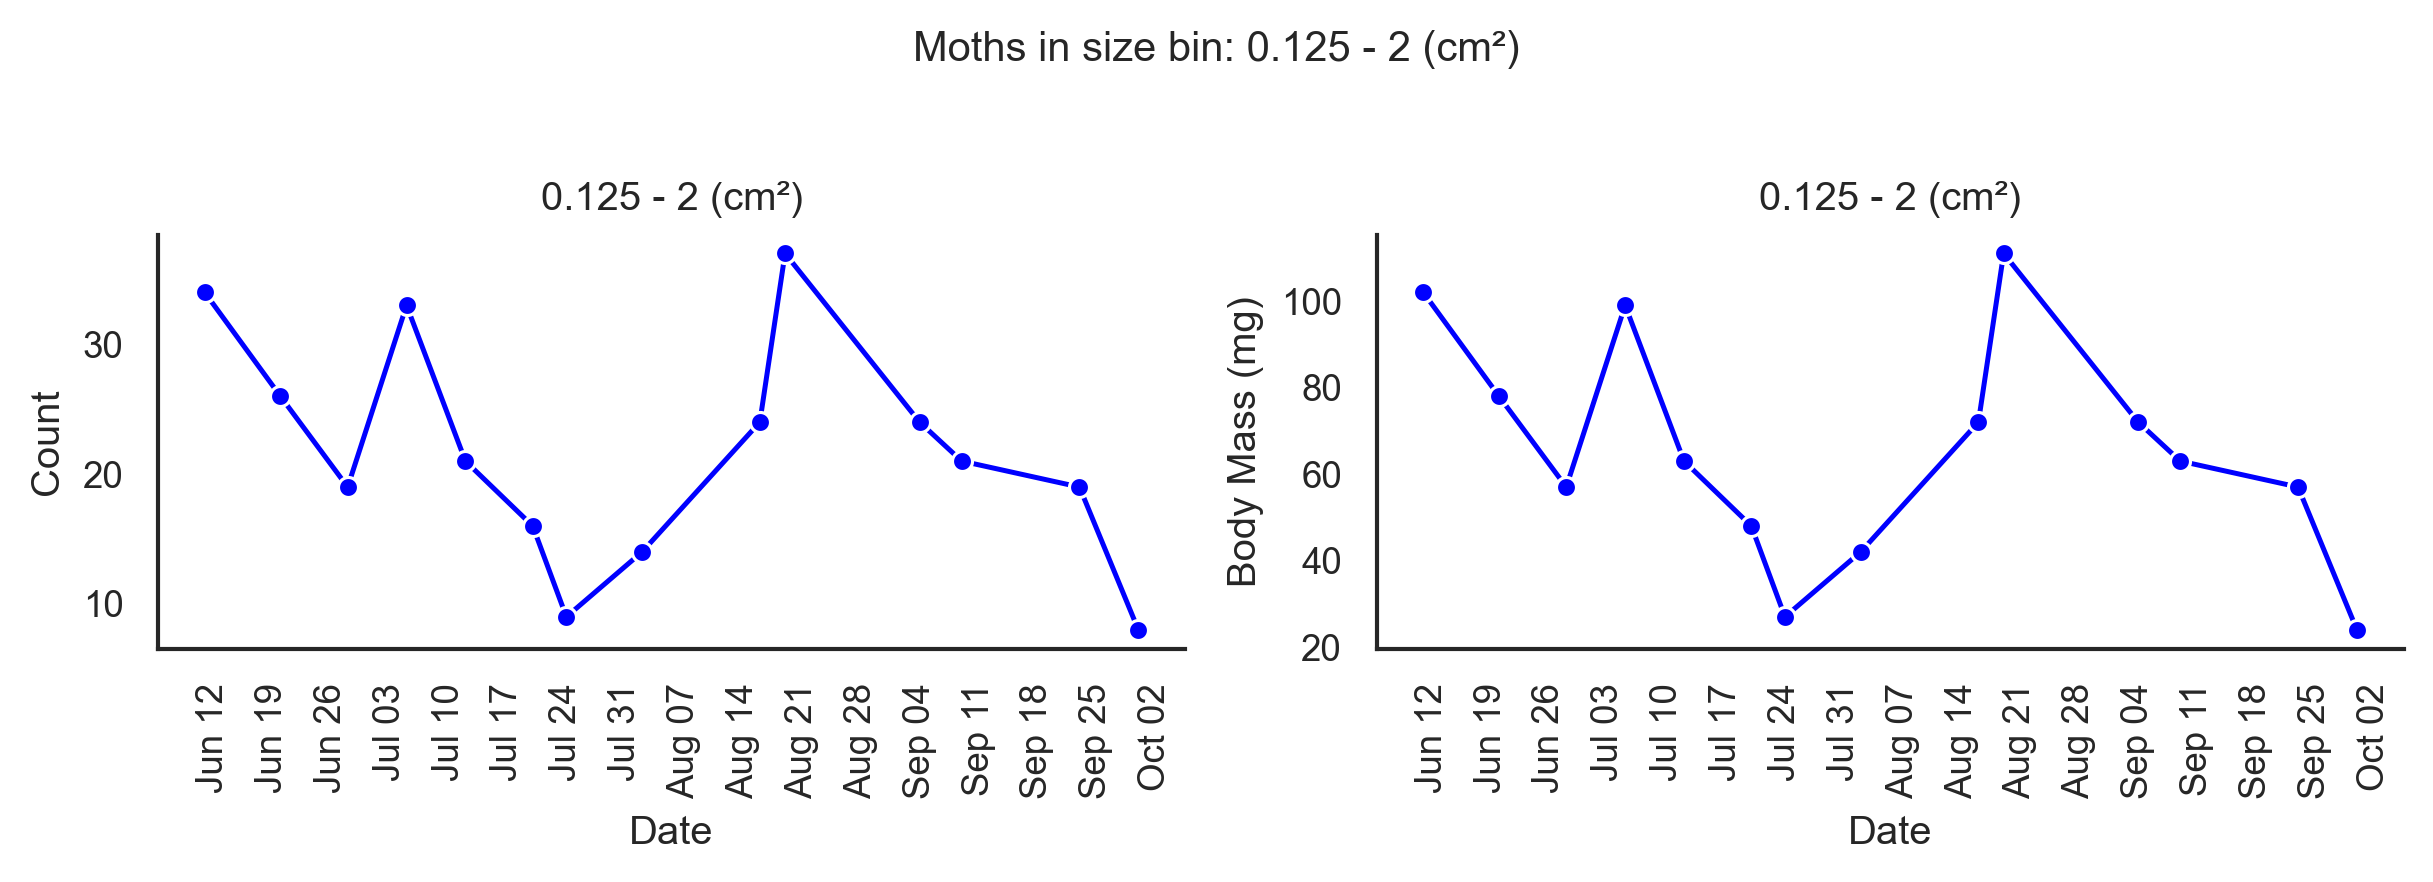

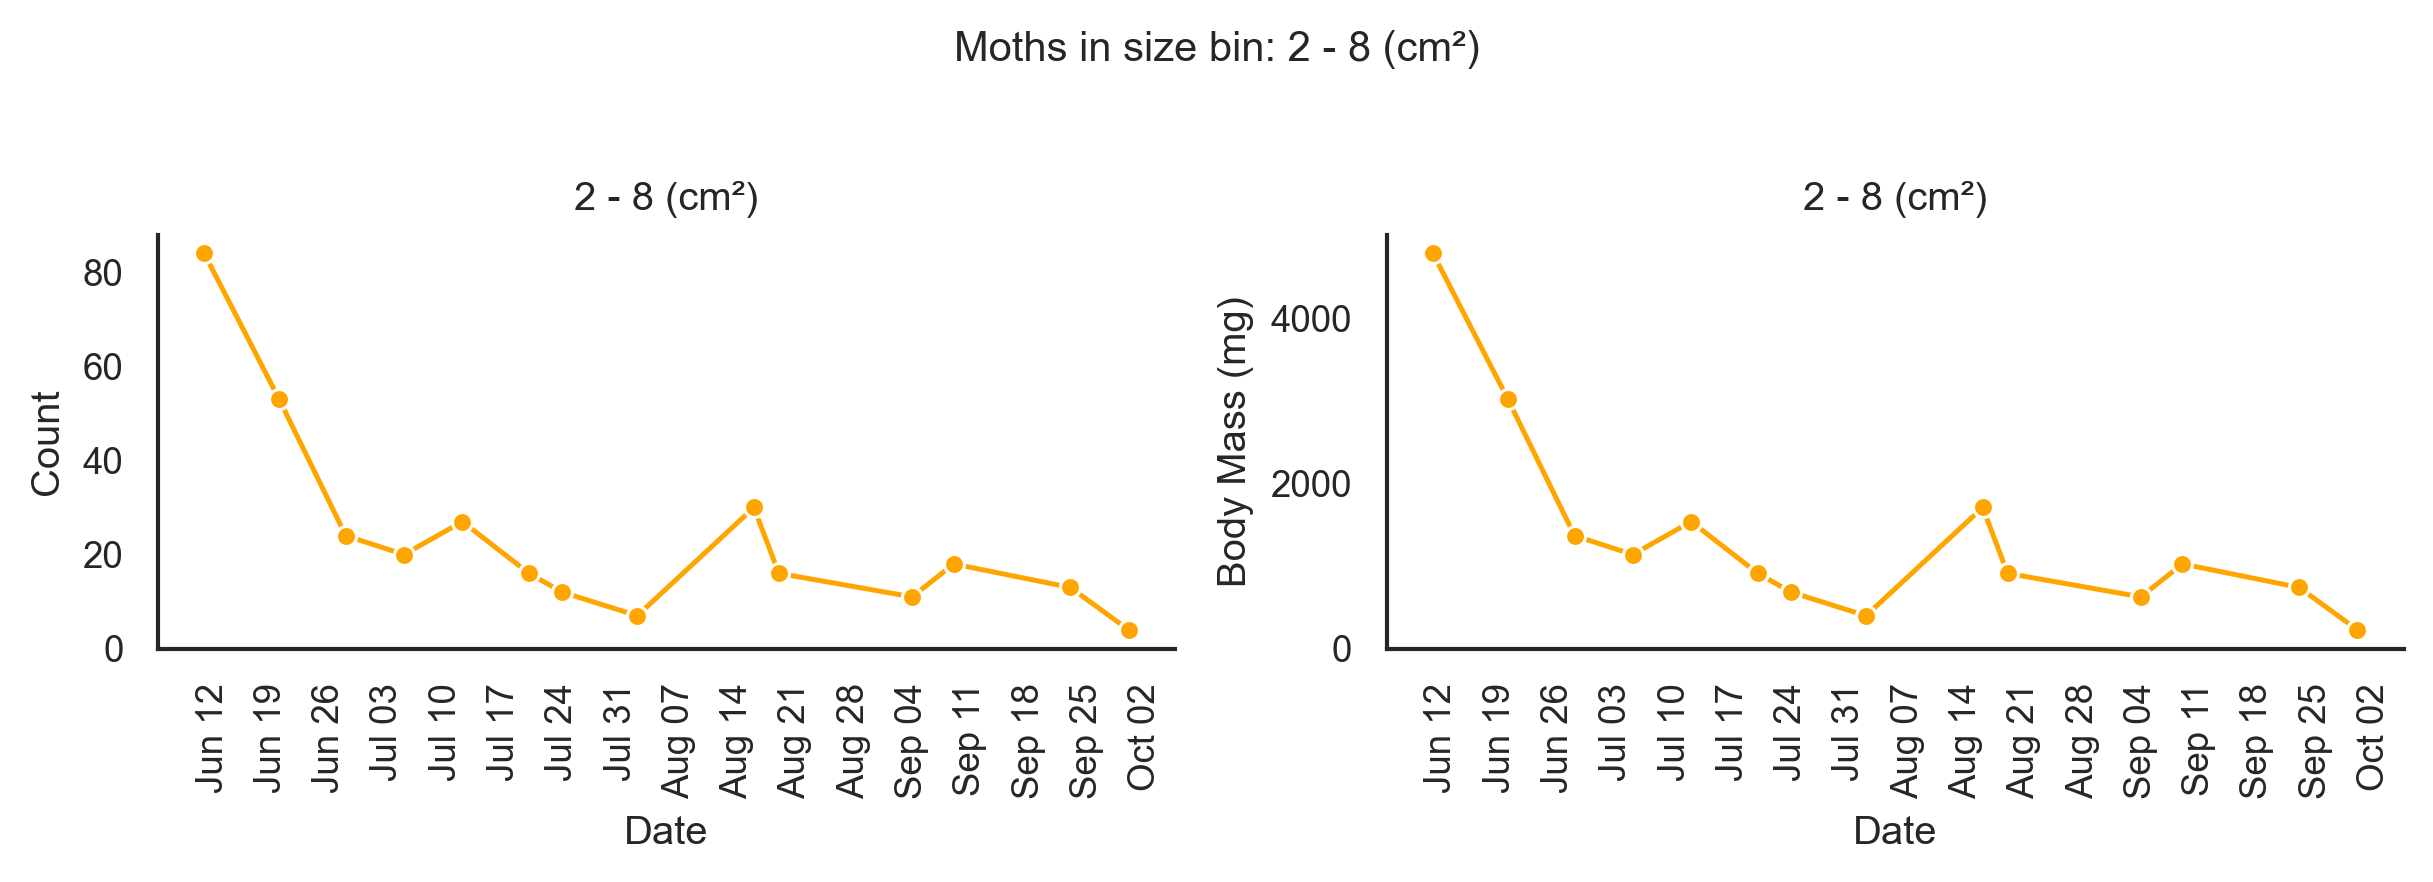

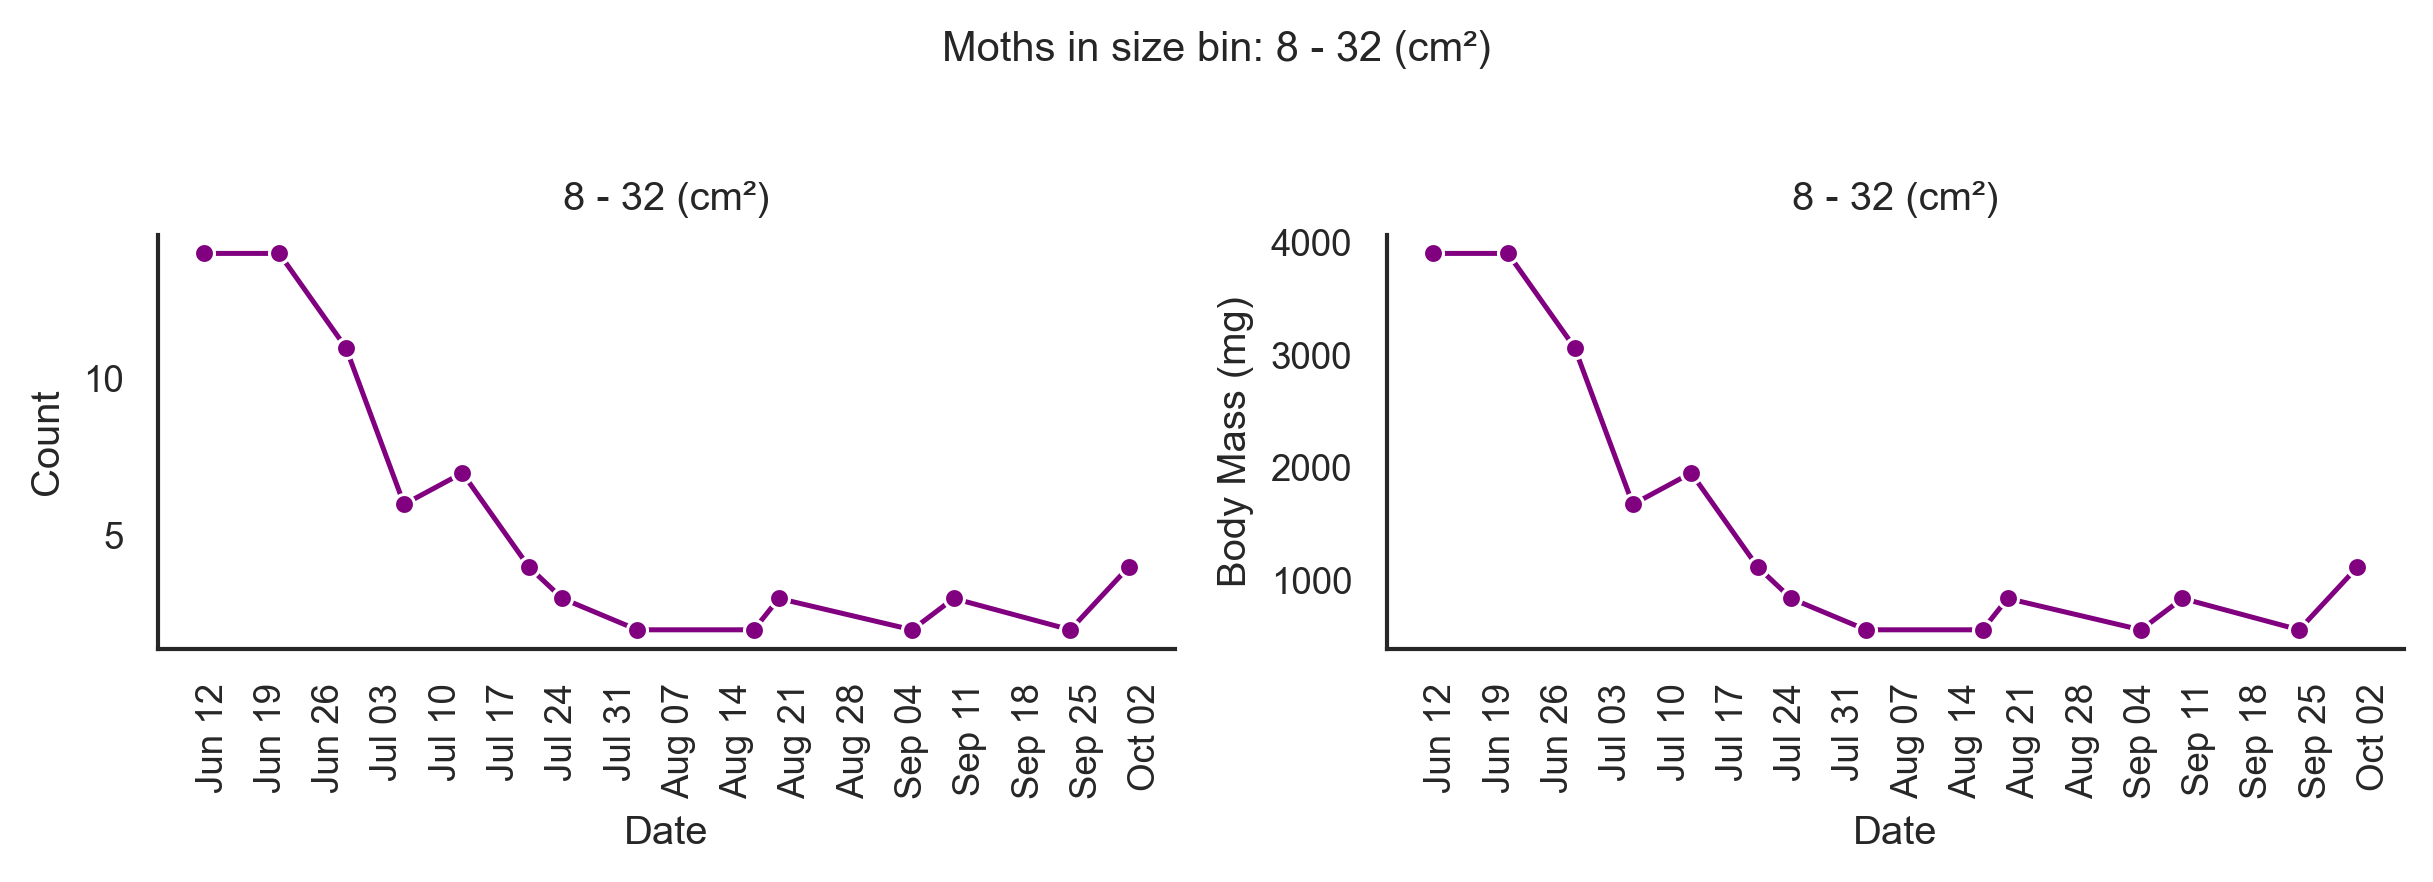

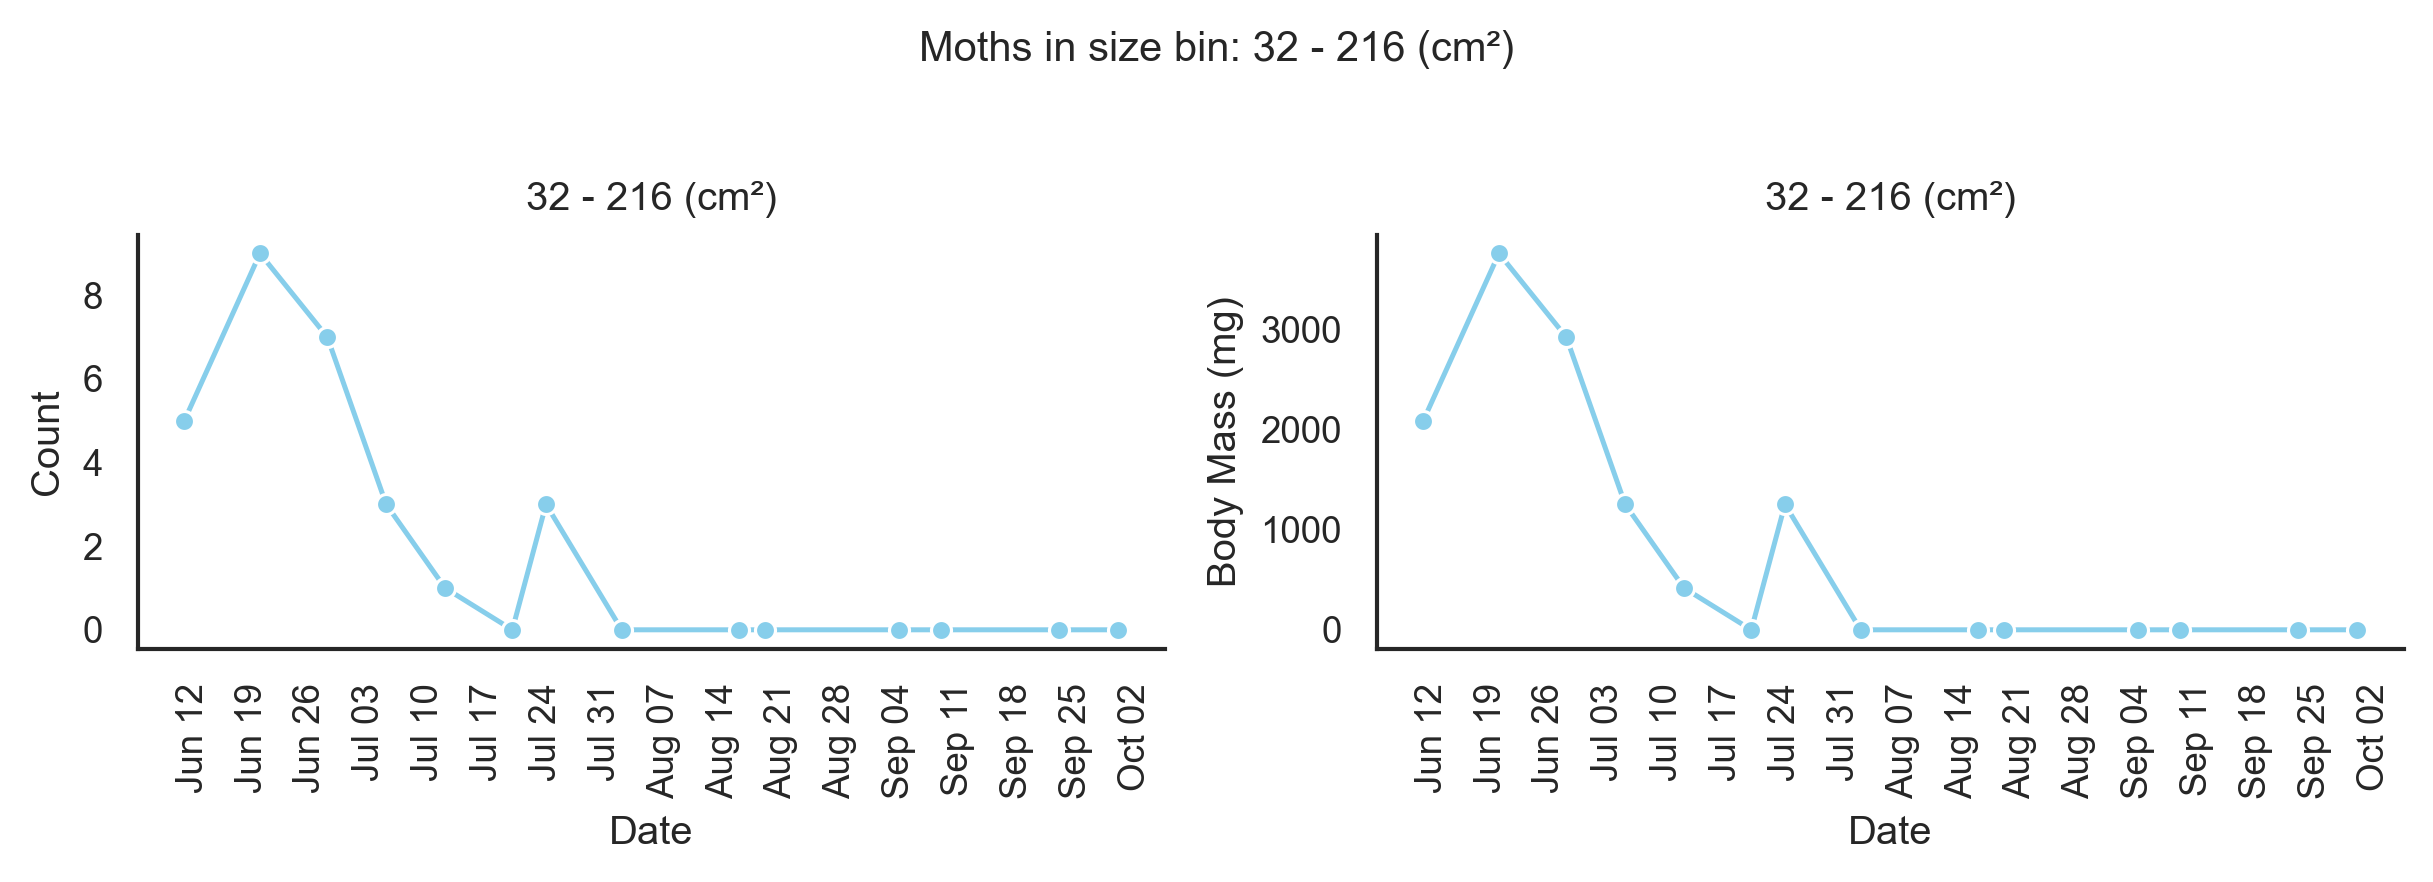

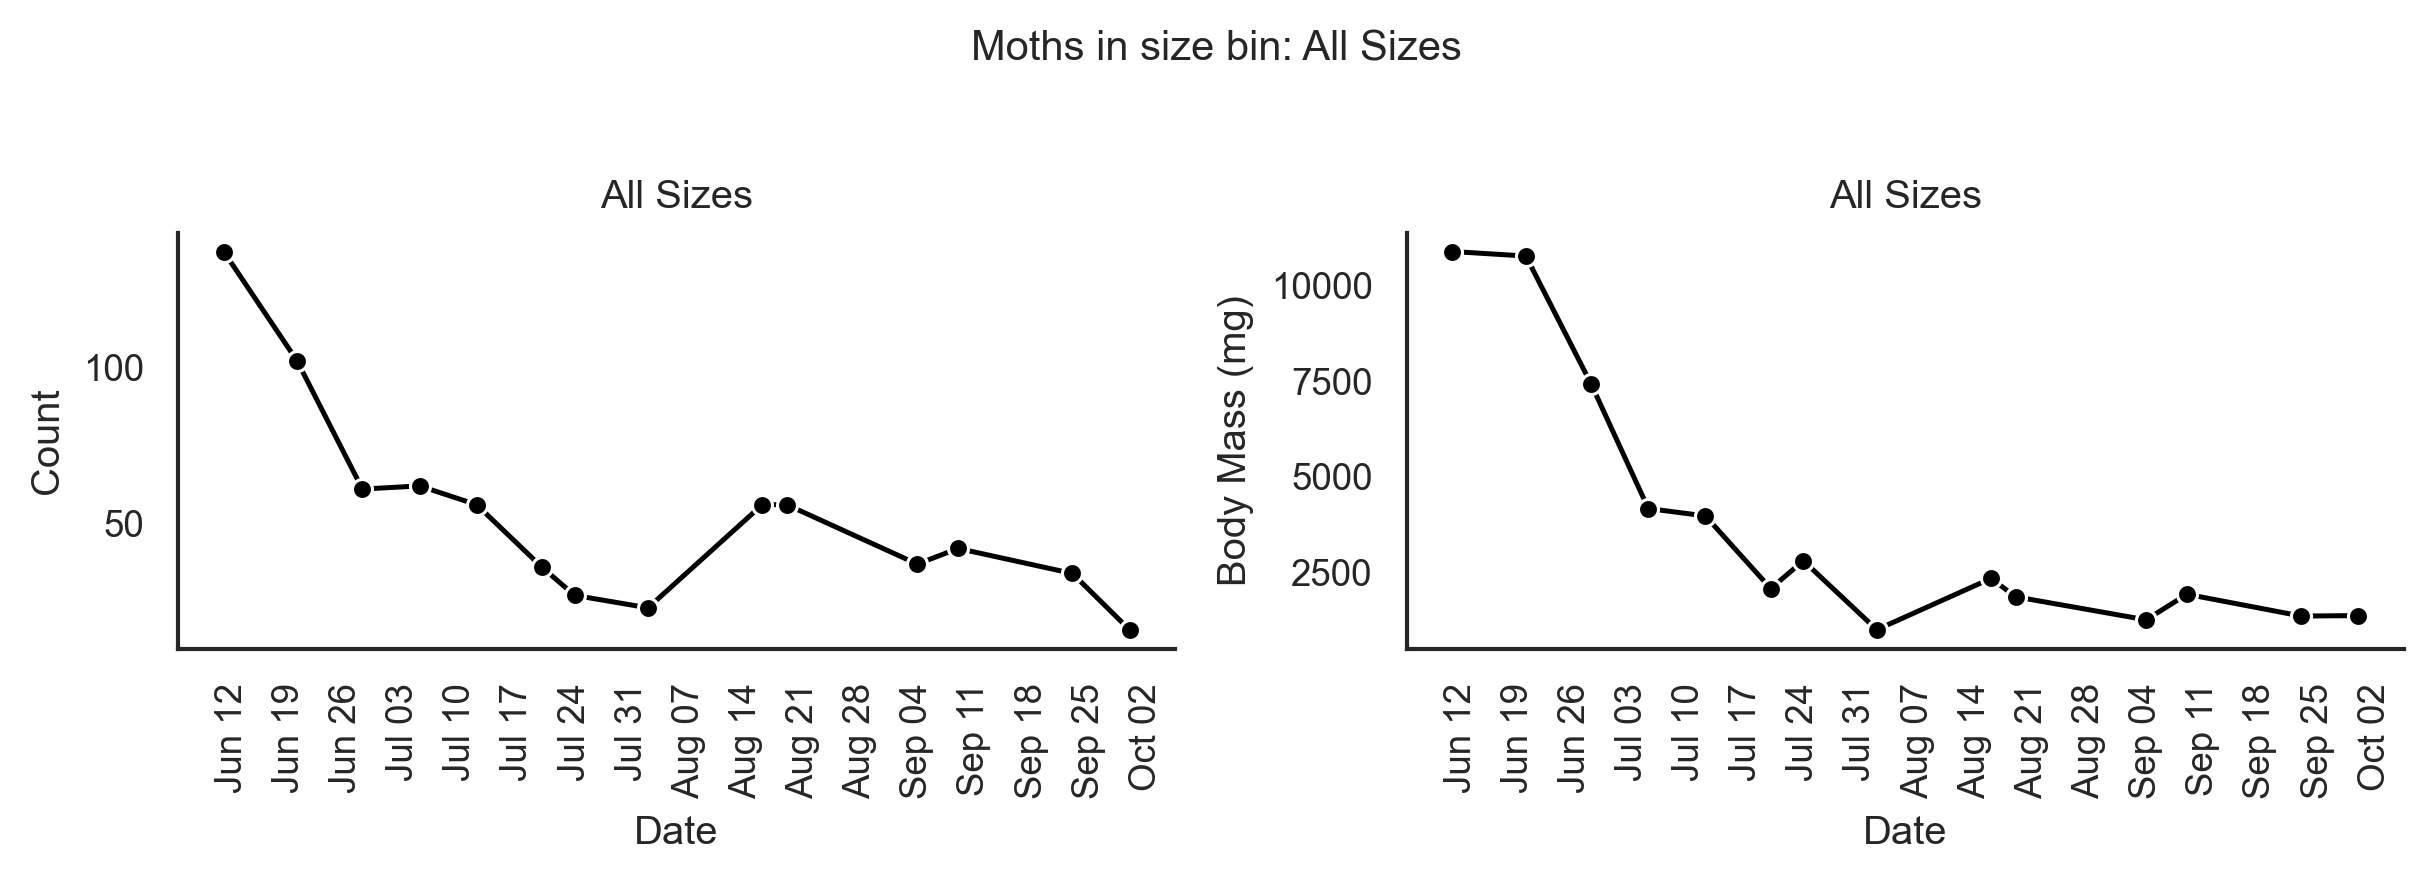

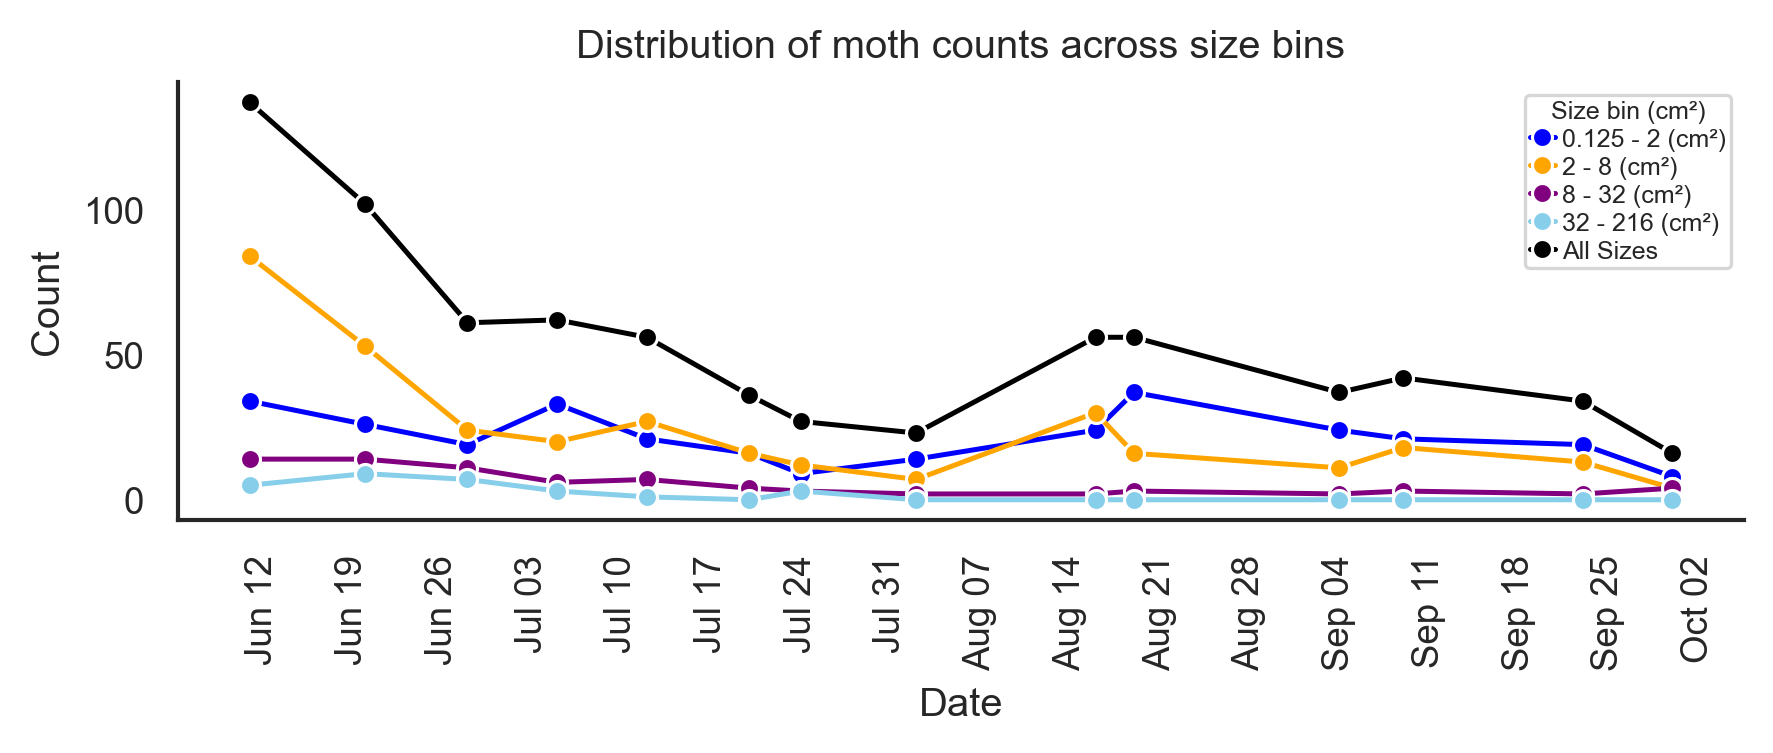

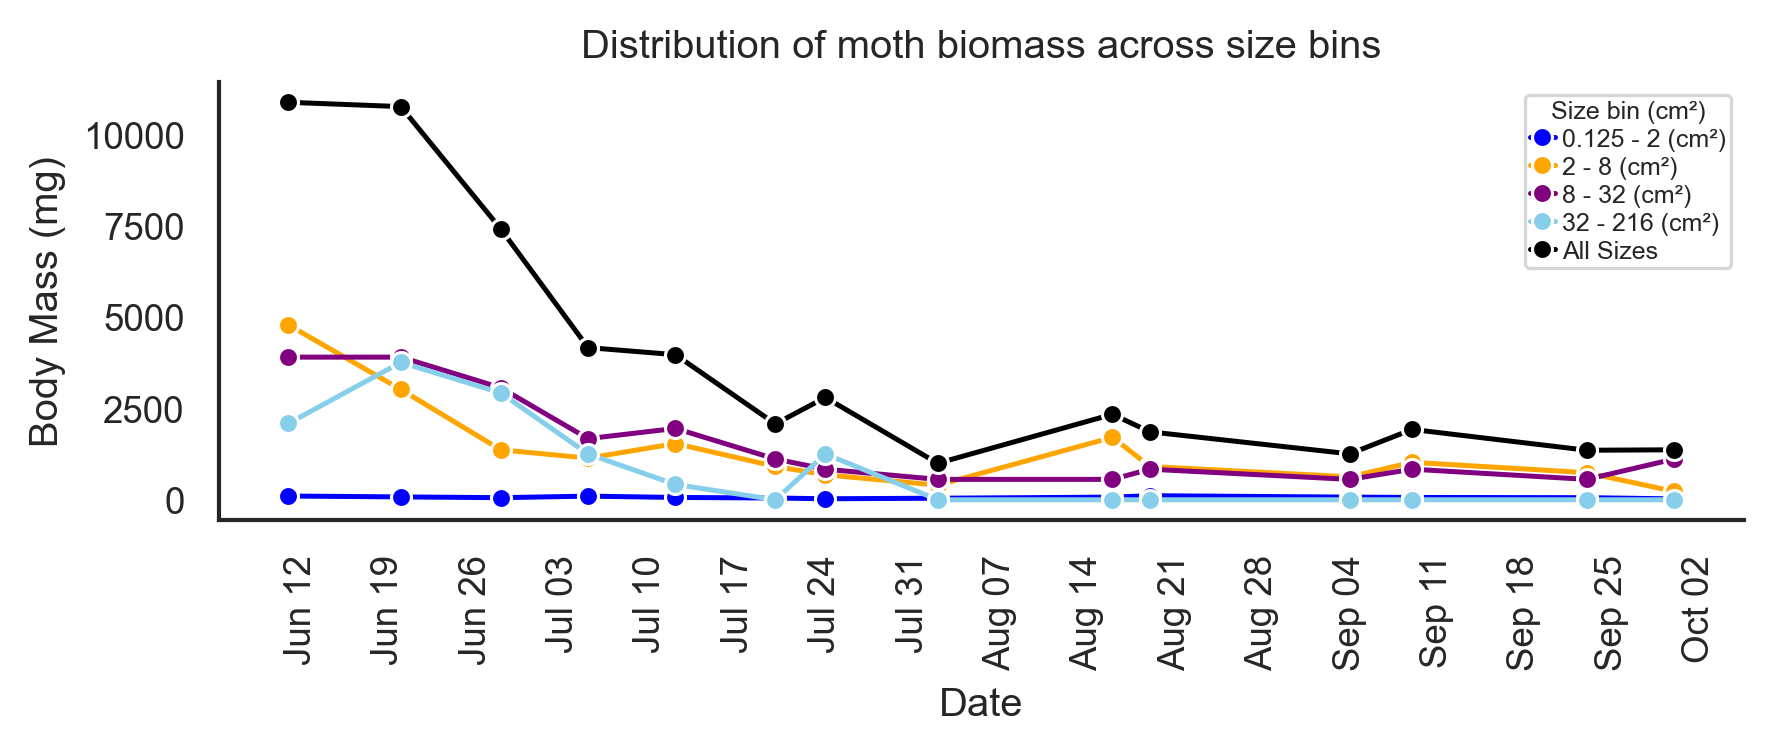

In [100]:
runtrends("2023", "WS1")

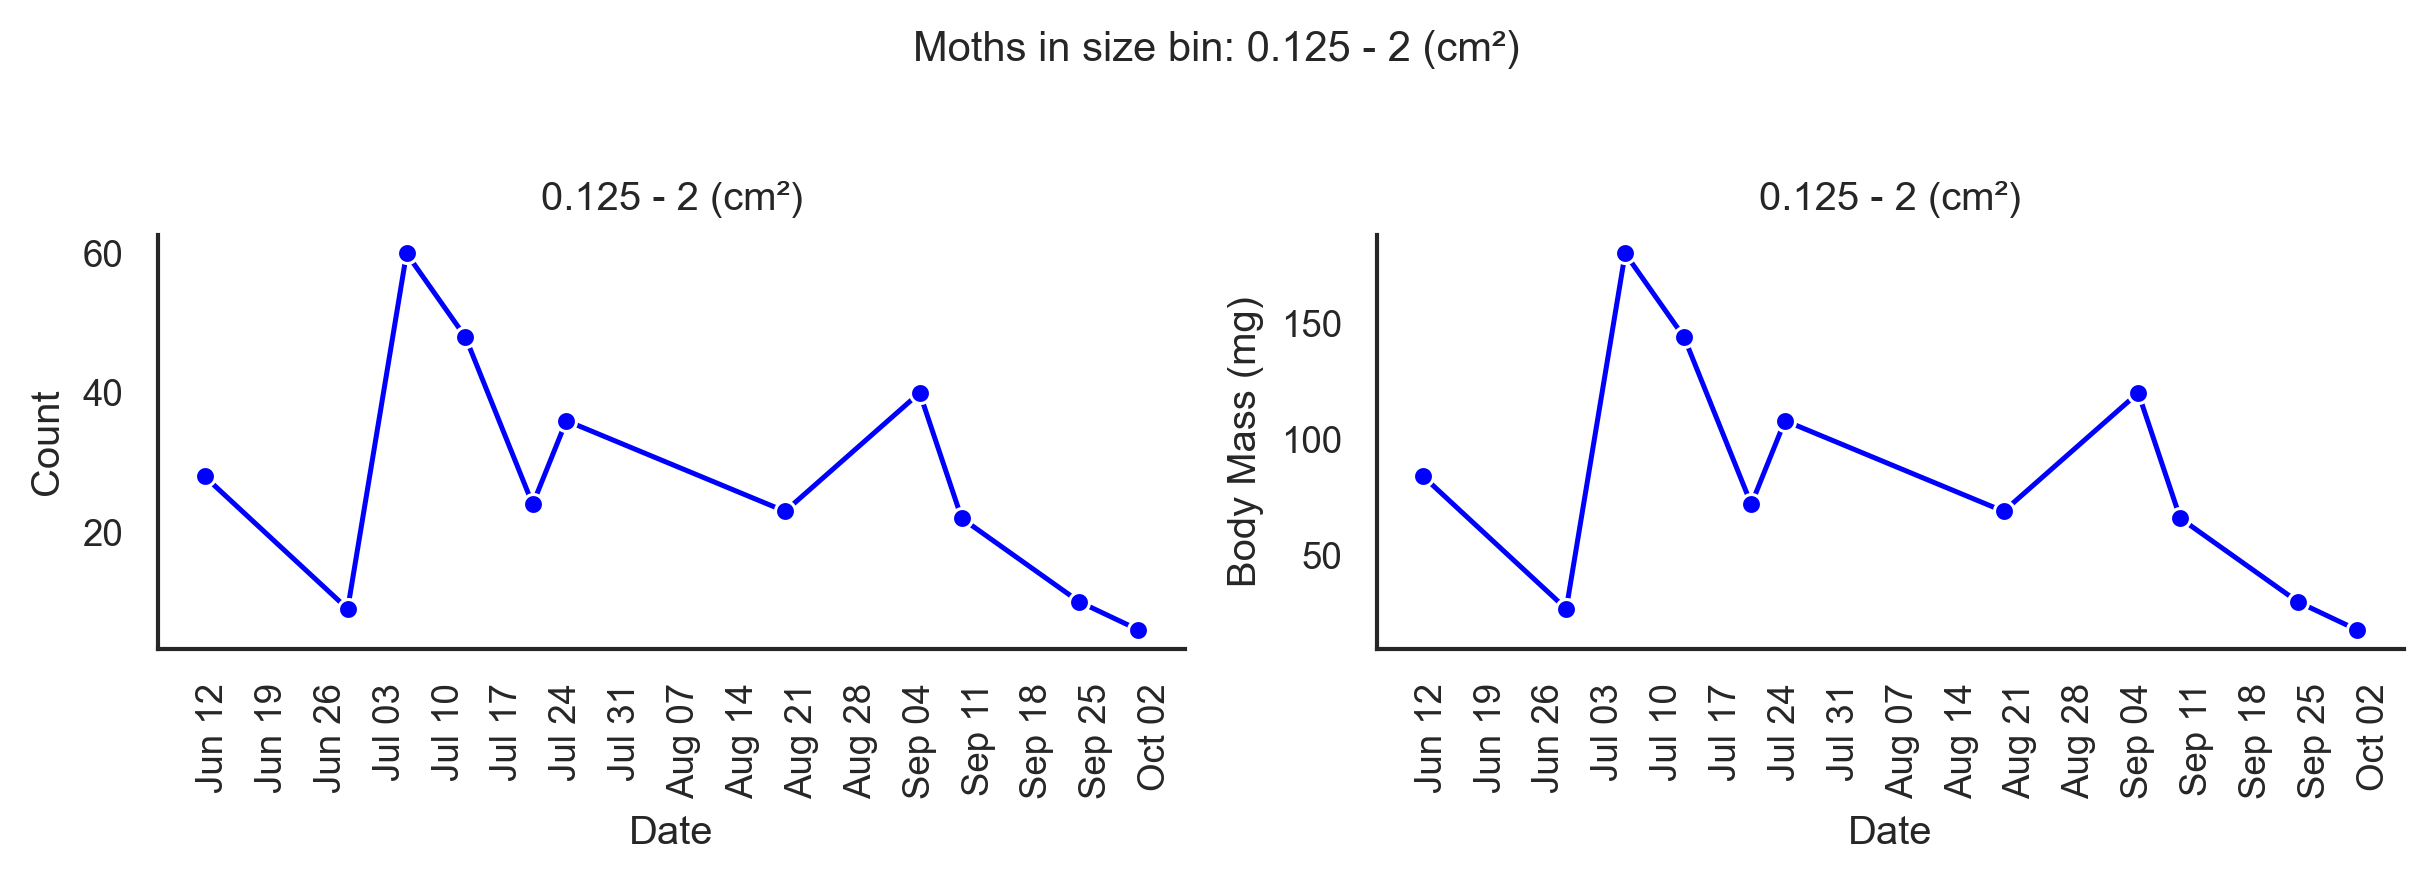

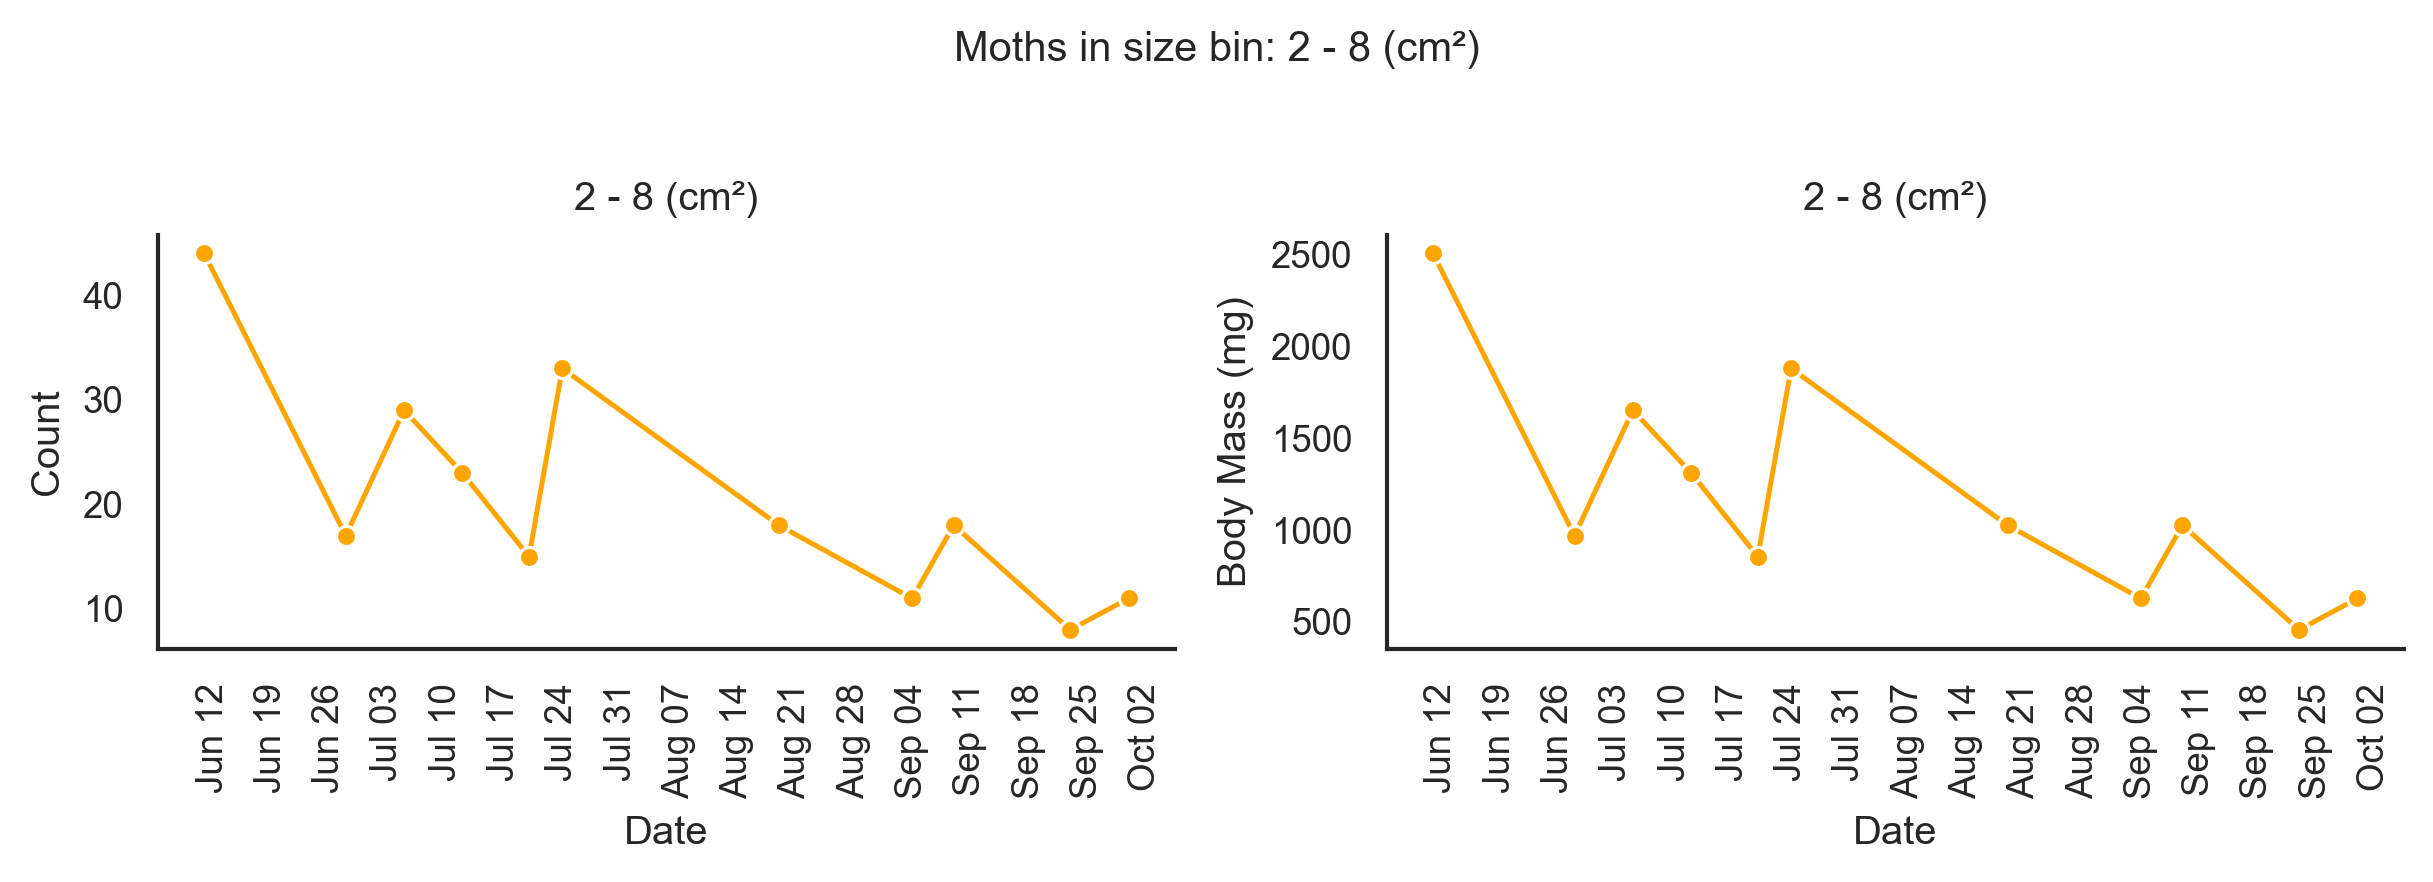

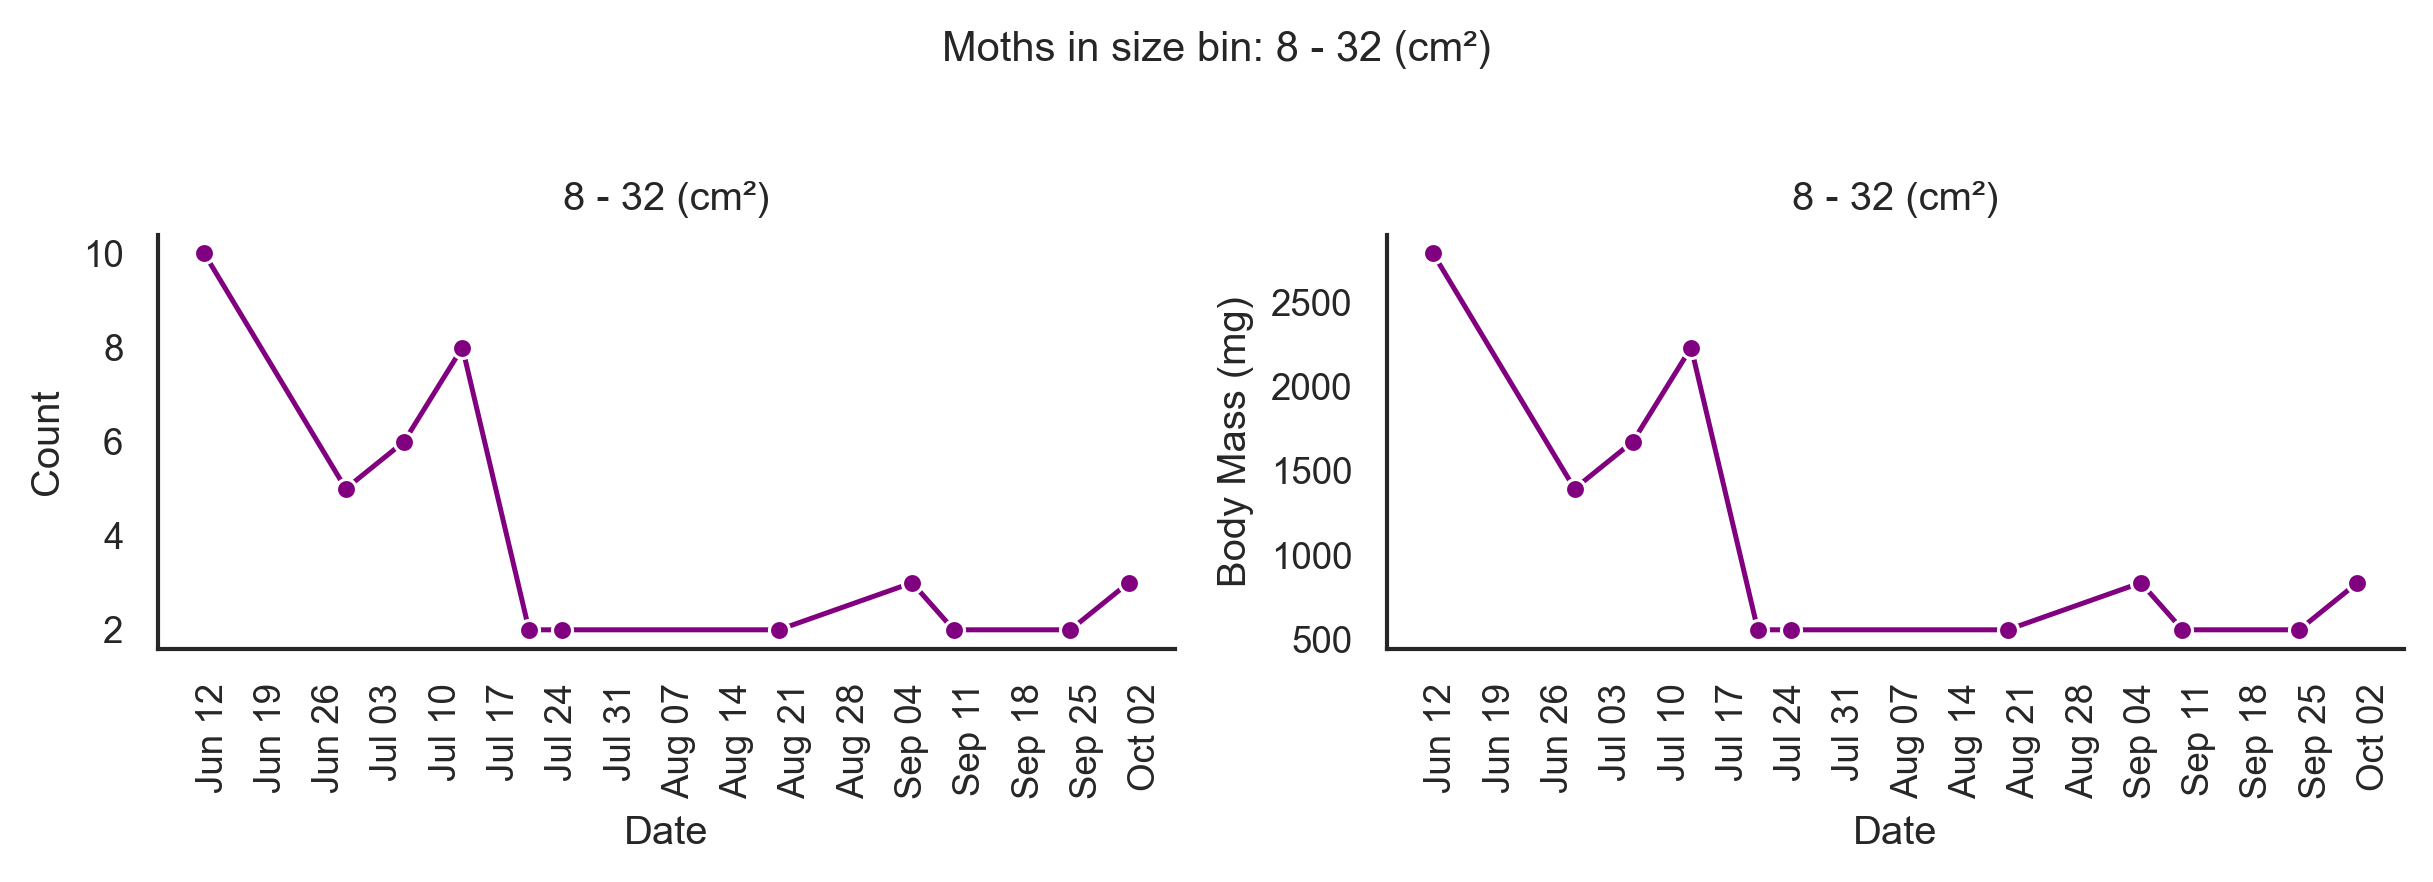

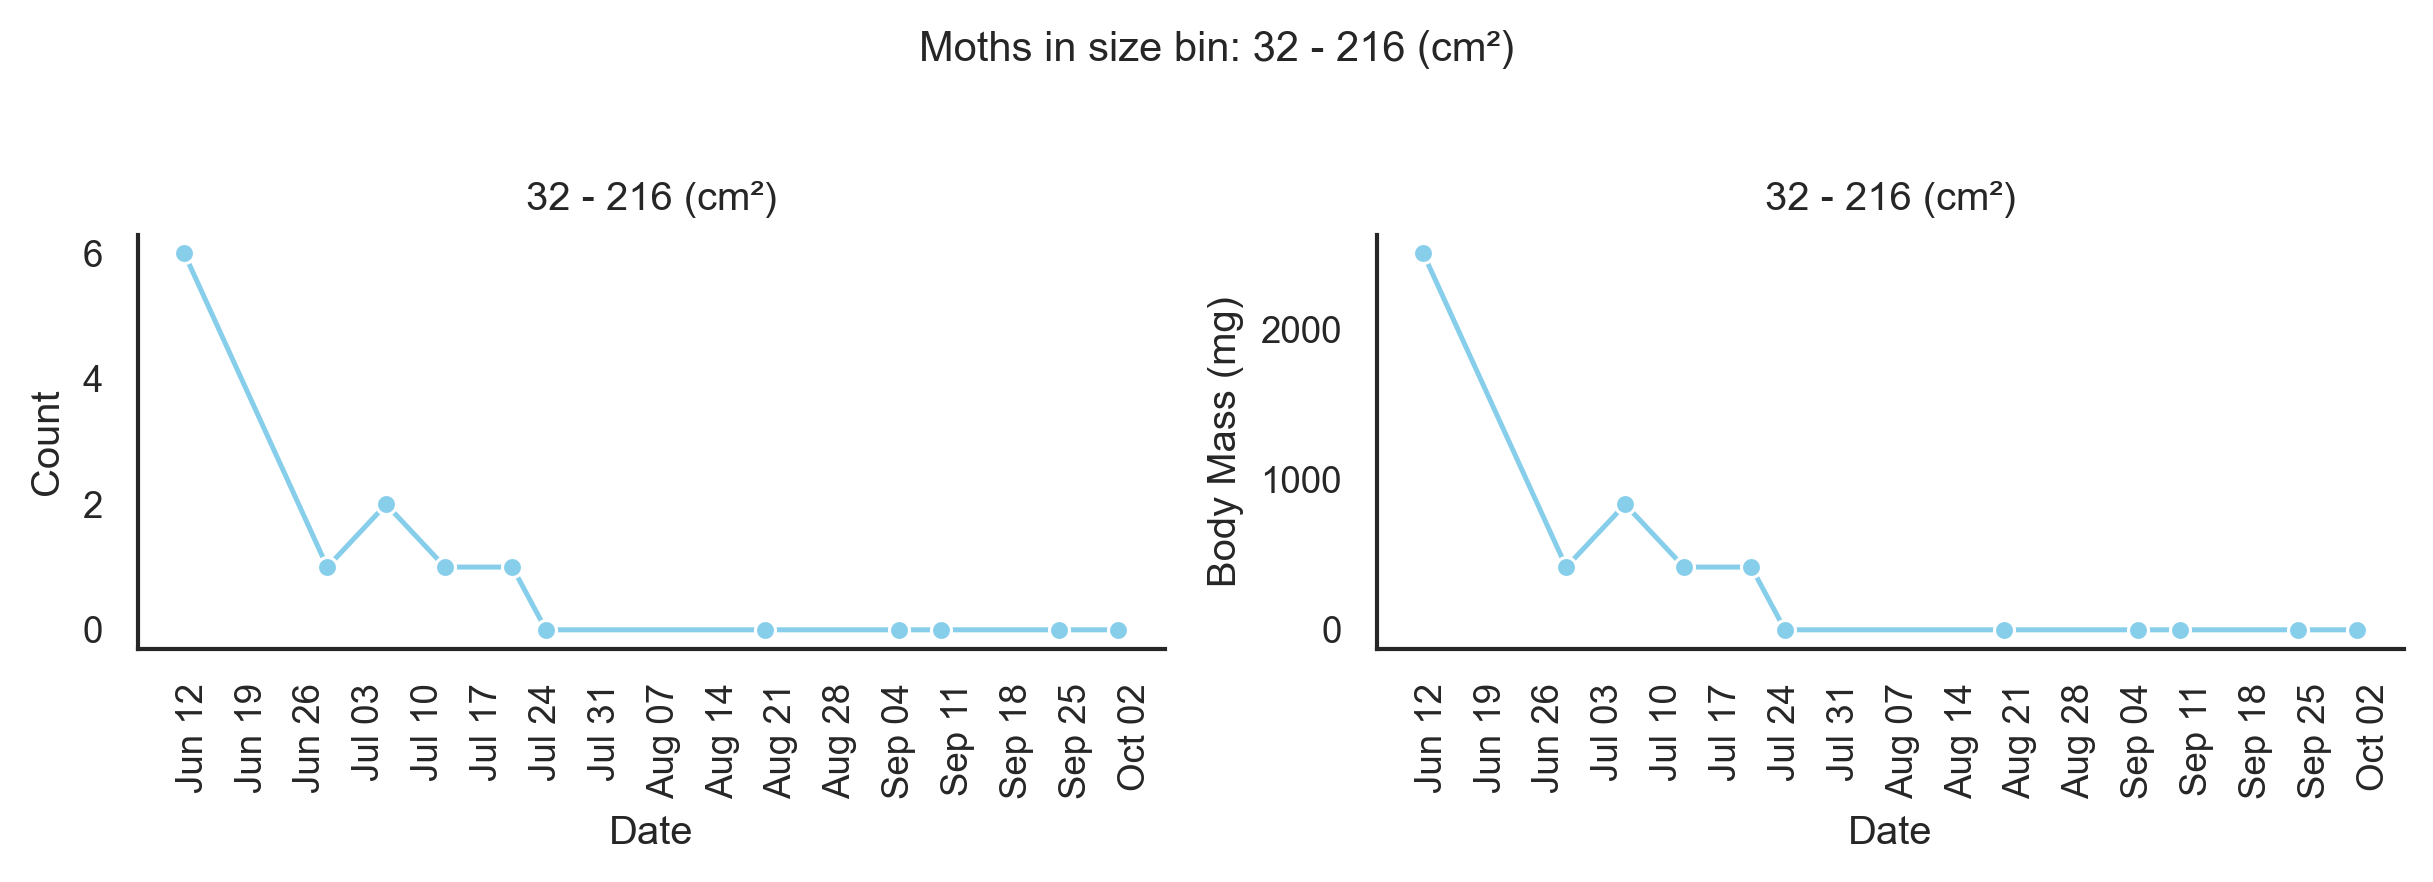

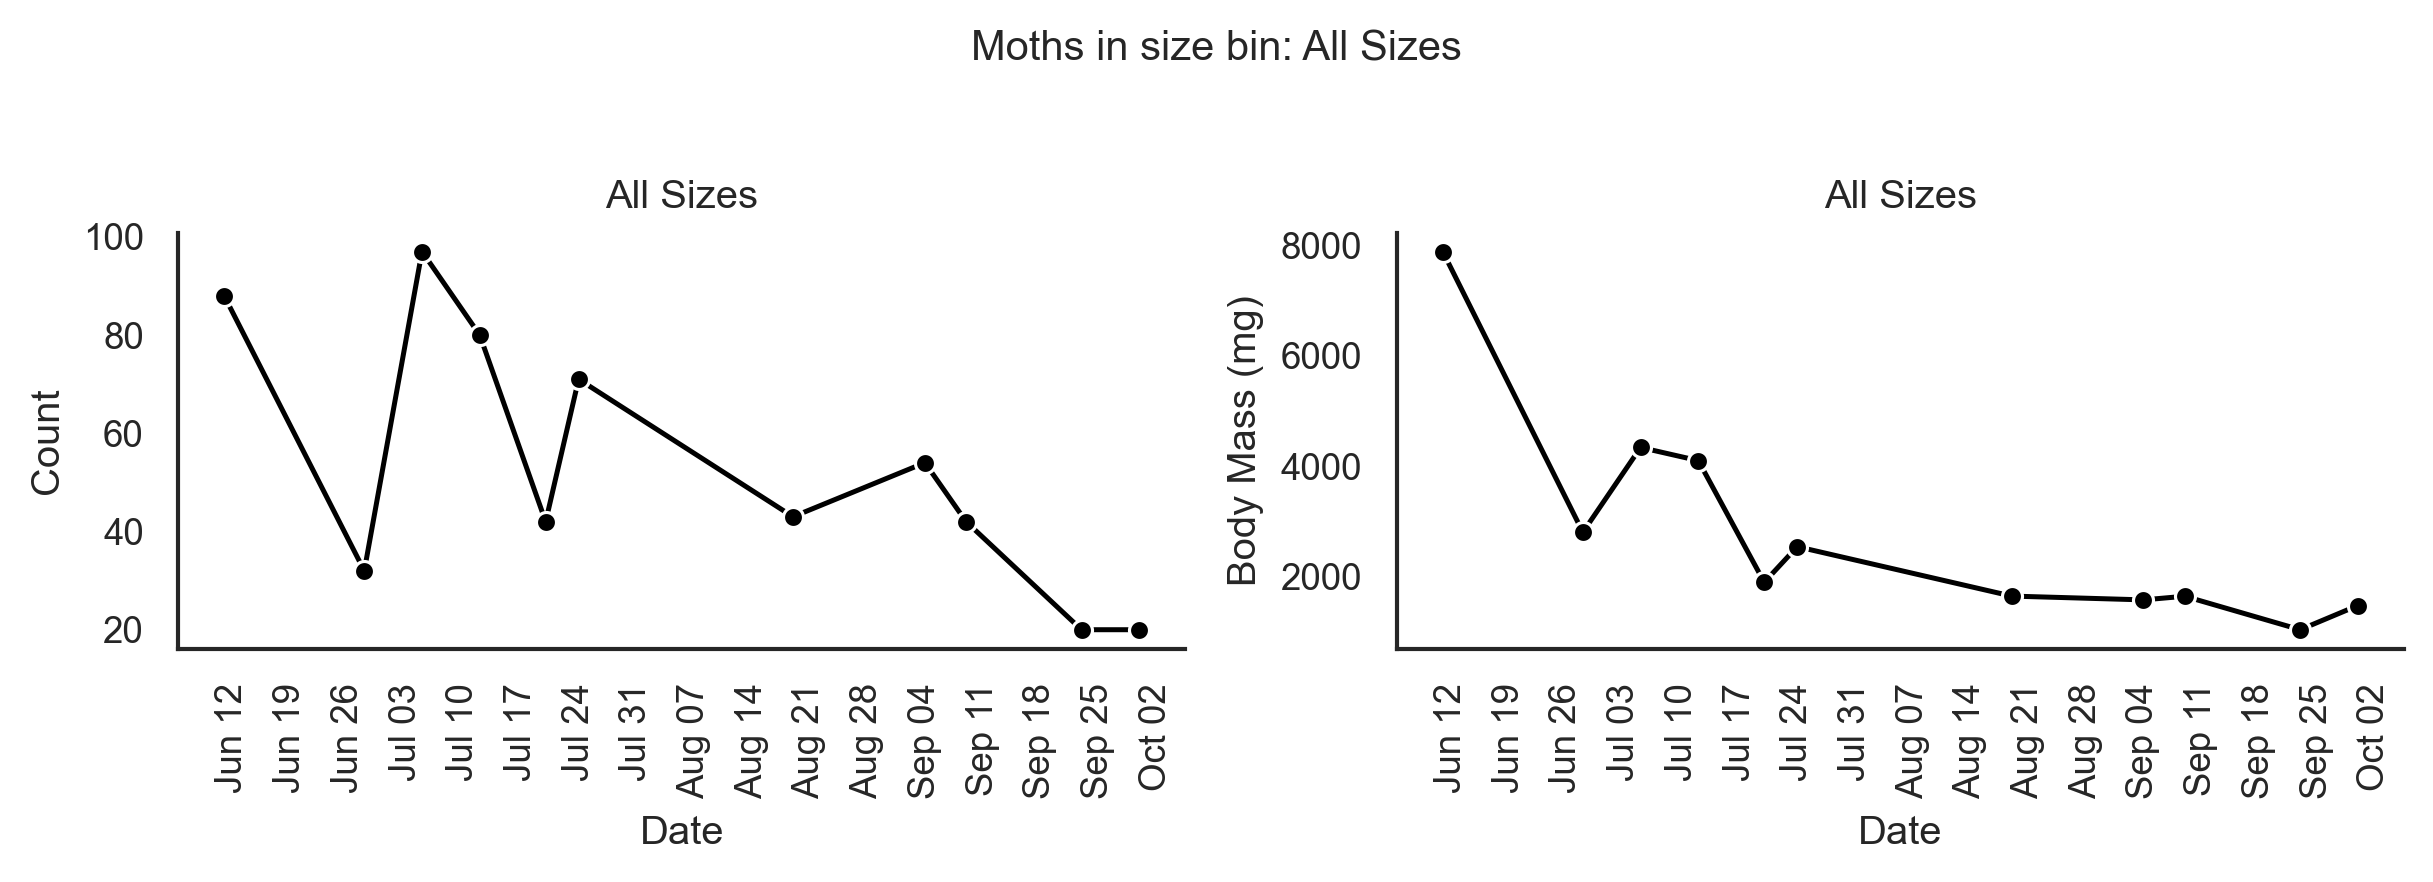

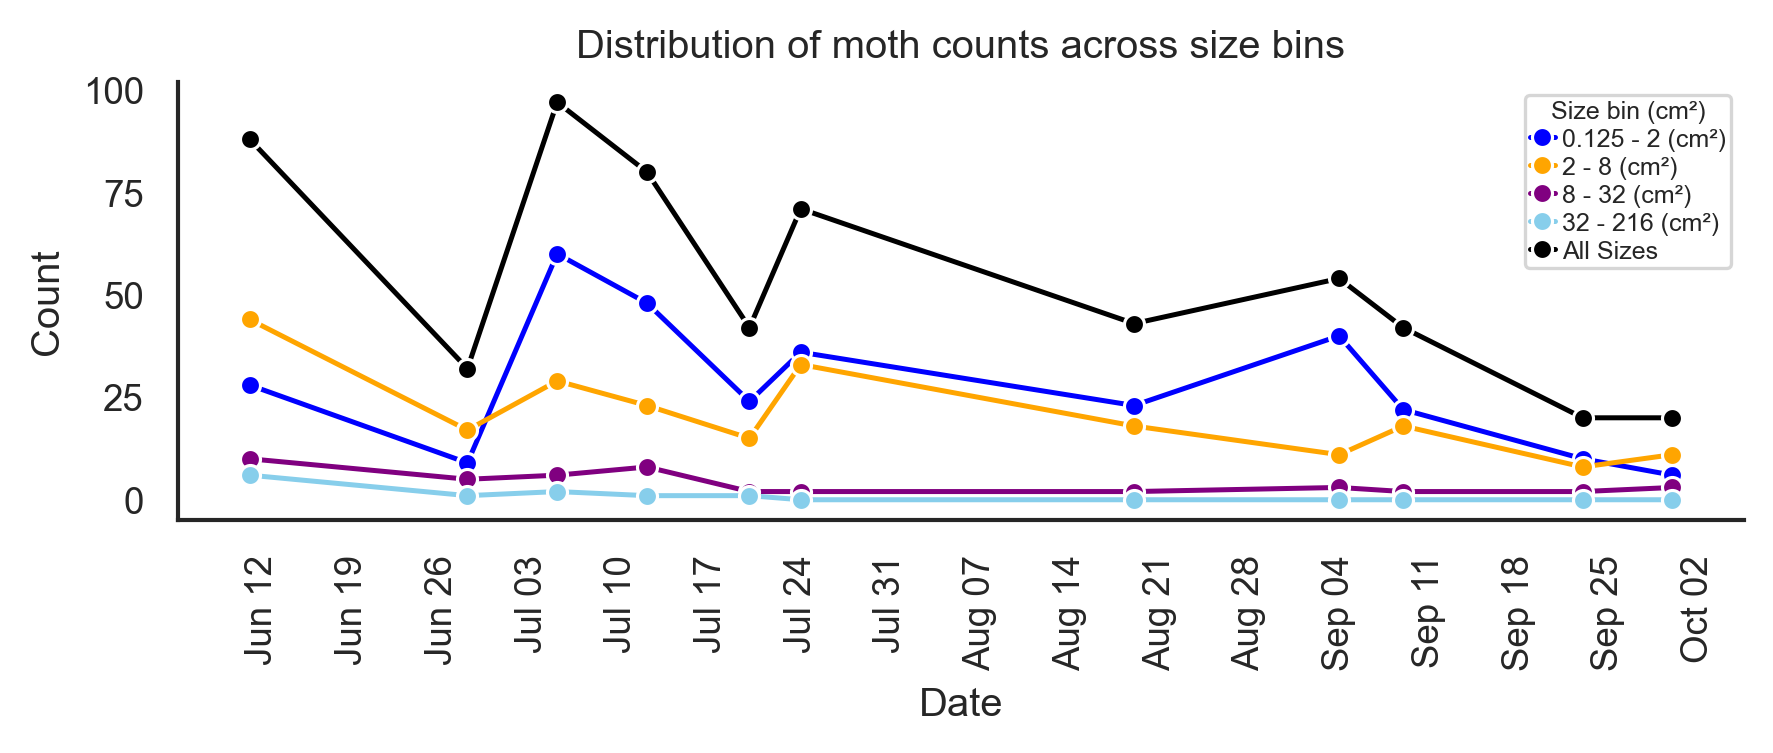

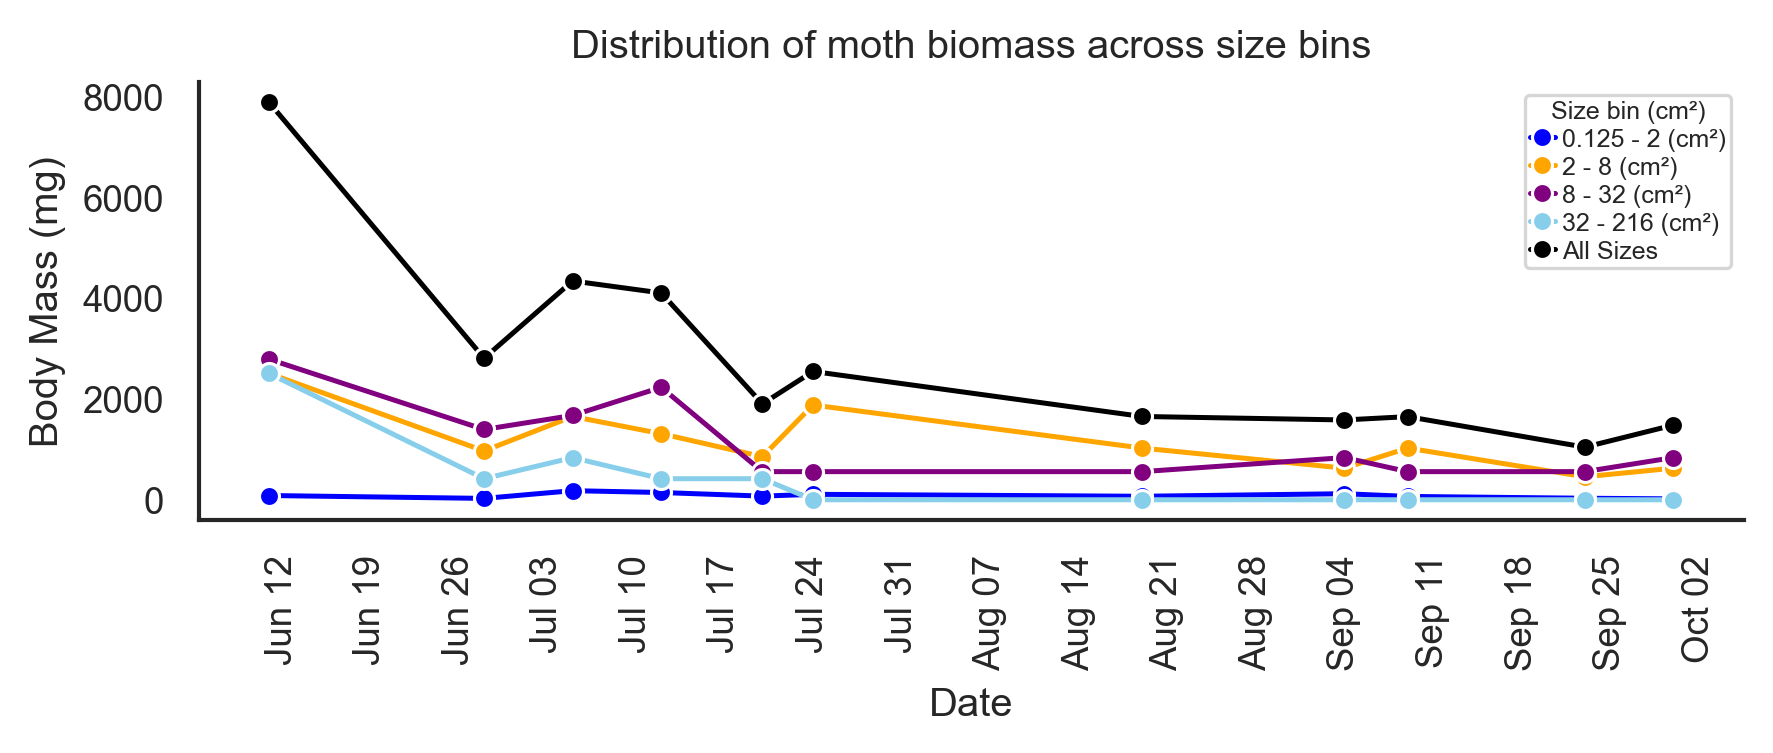

In [101]:
runtrends("2023", "WS4")

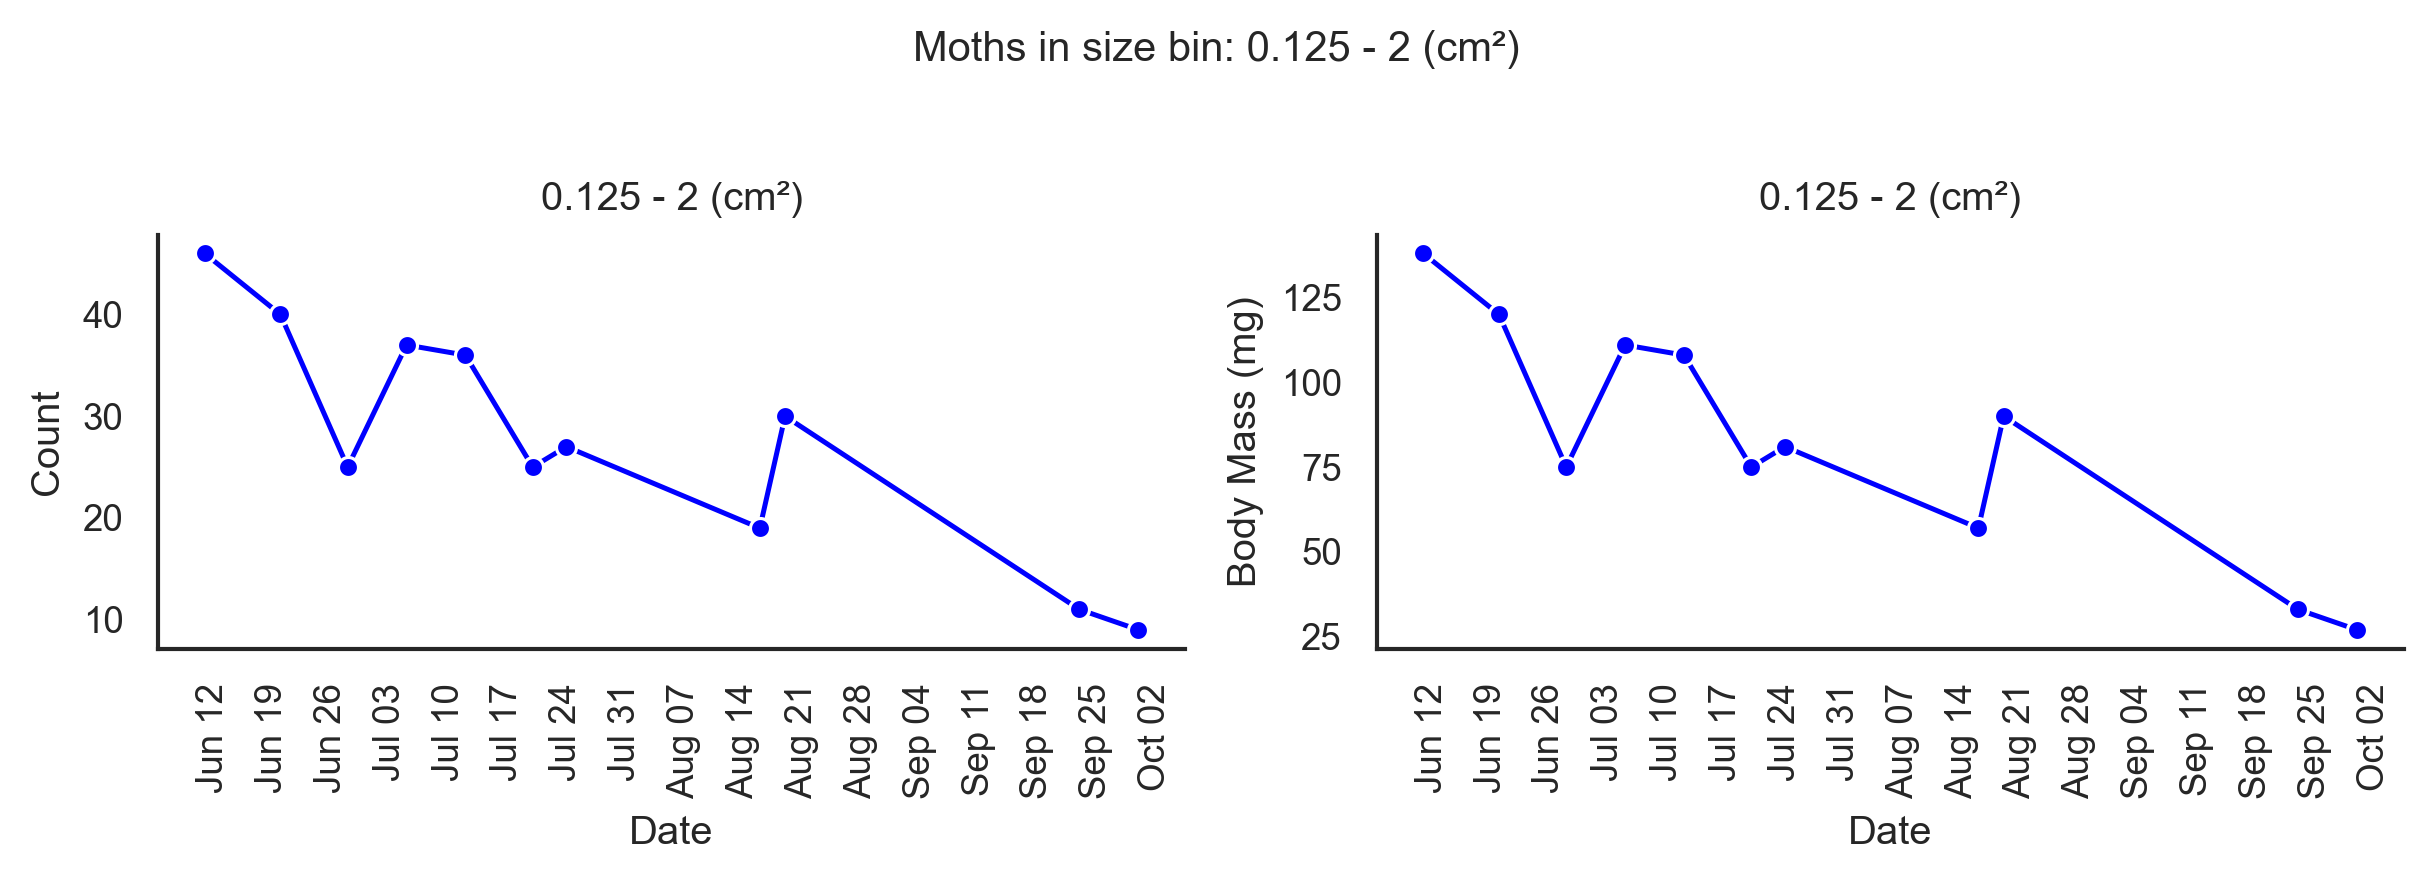

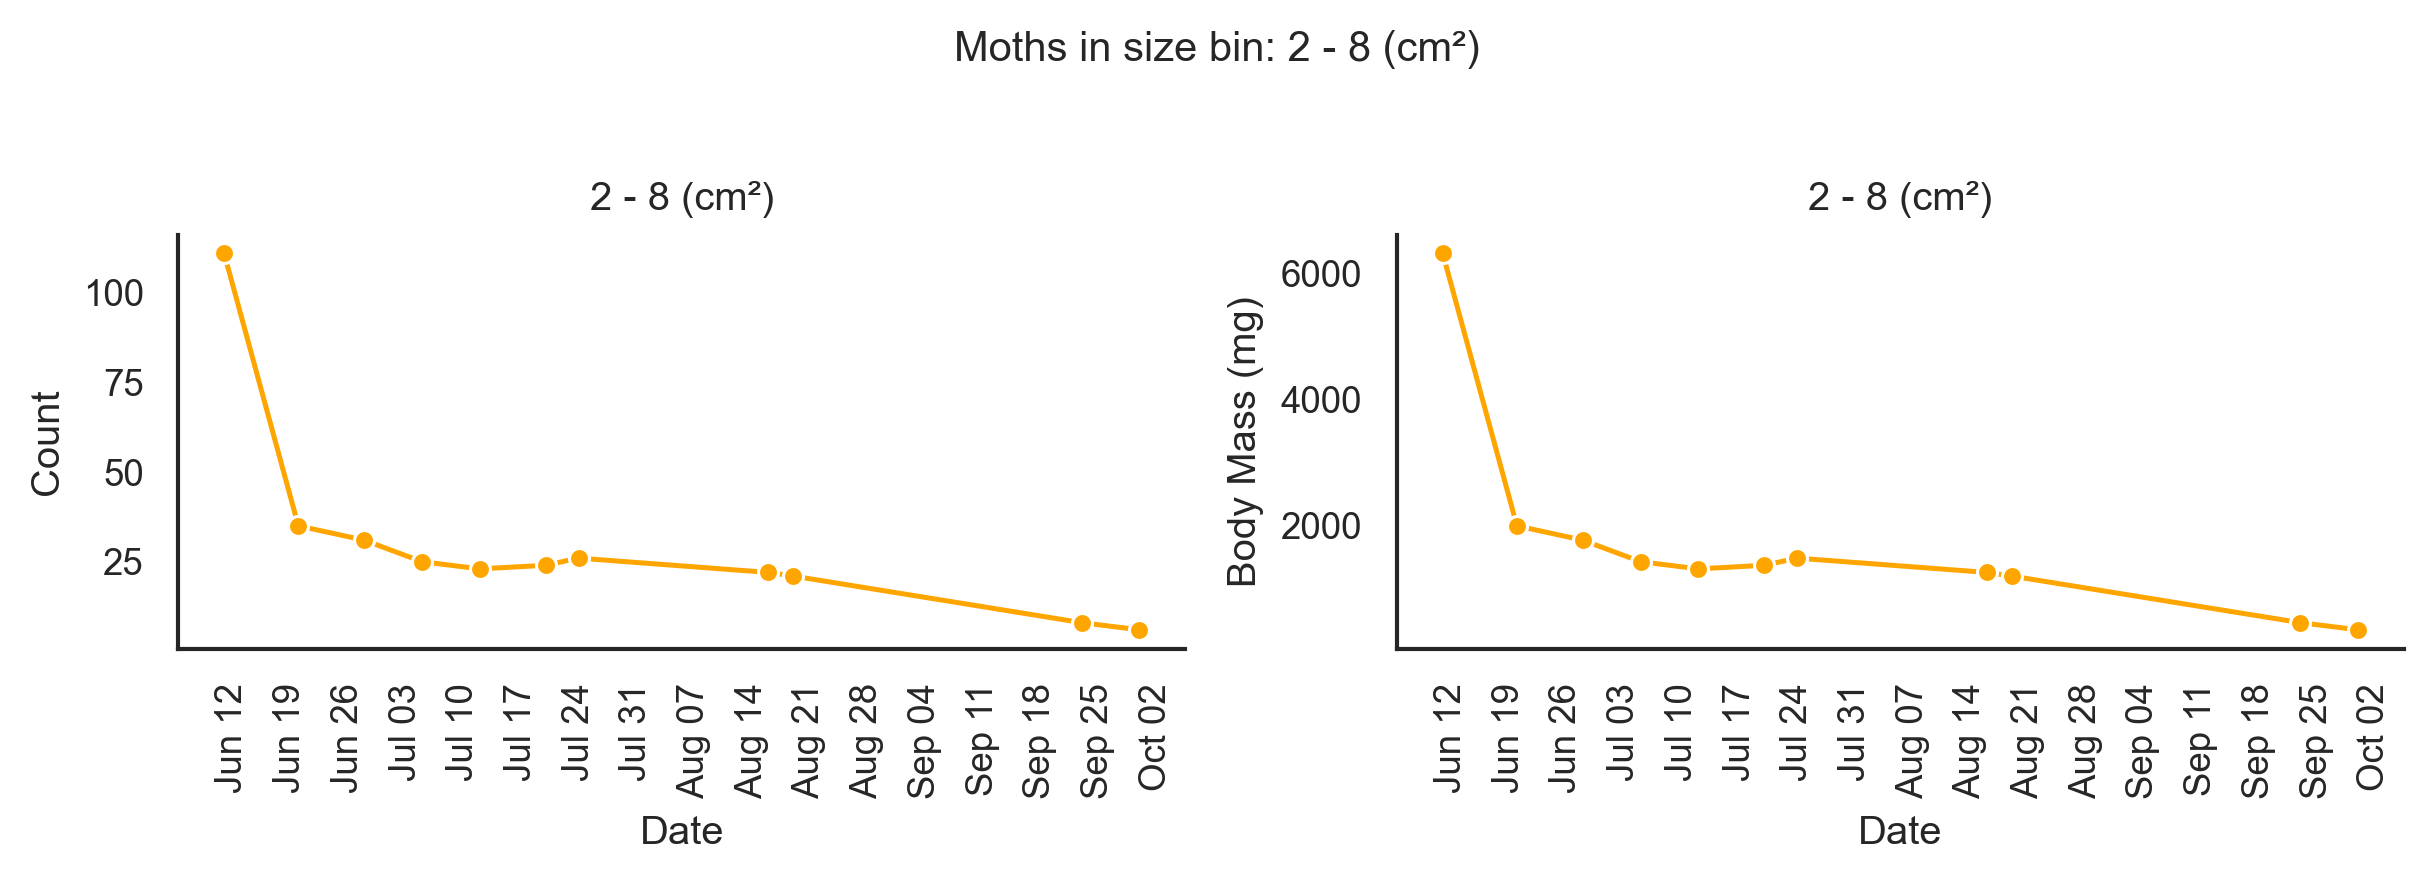

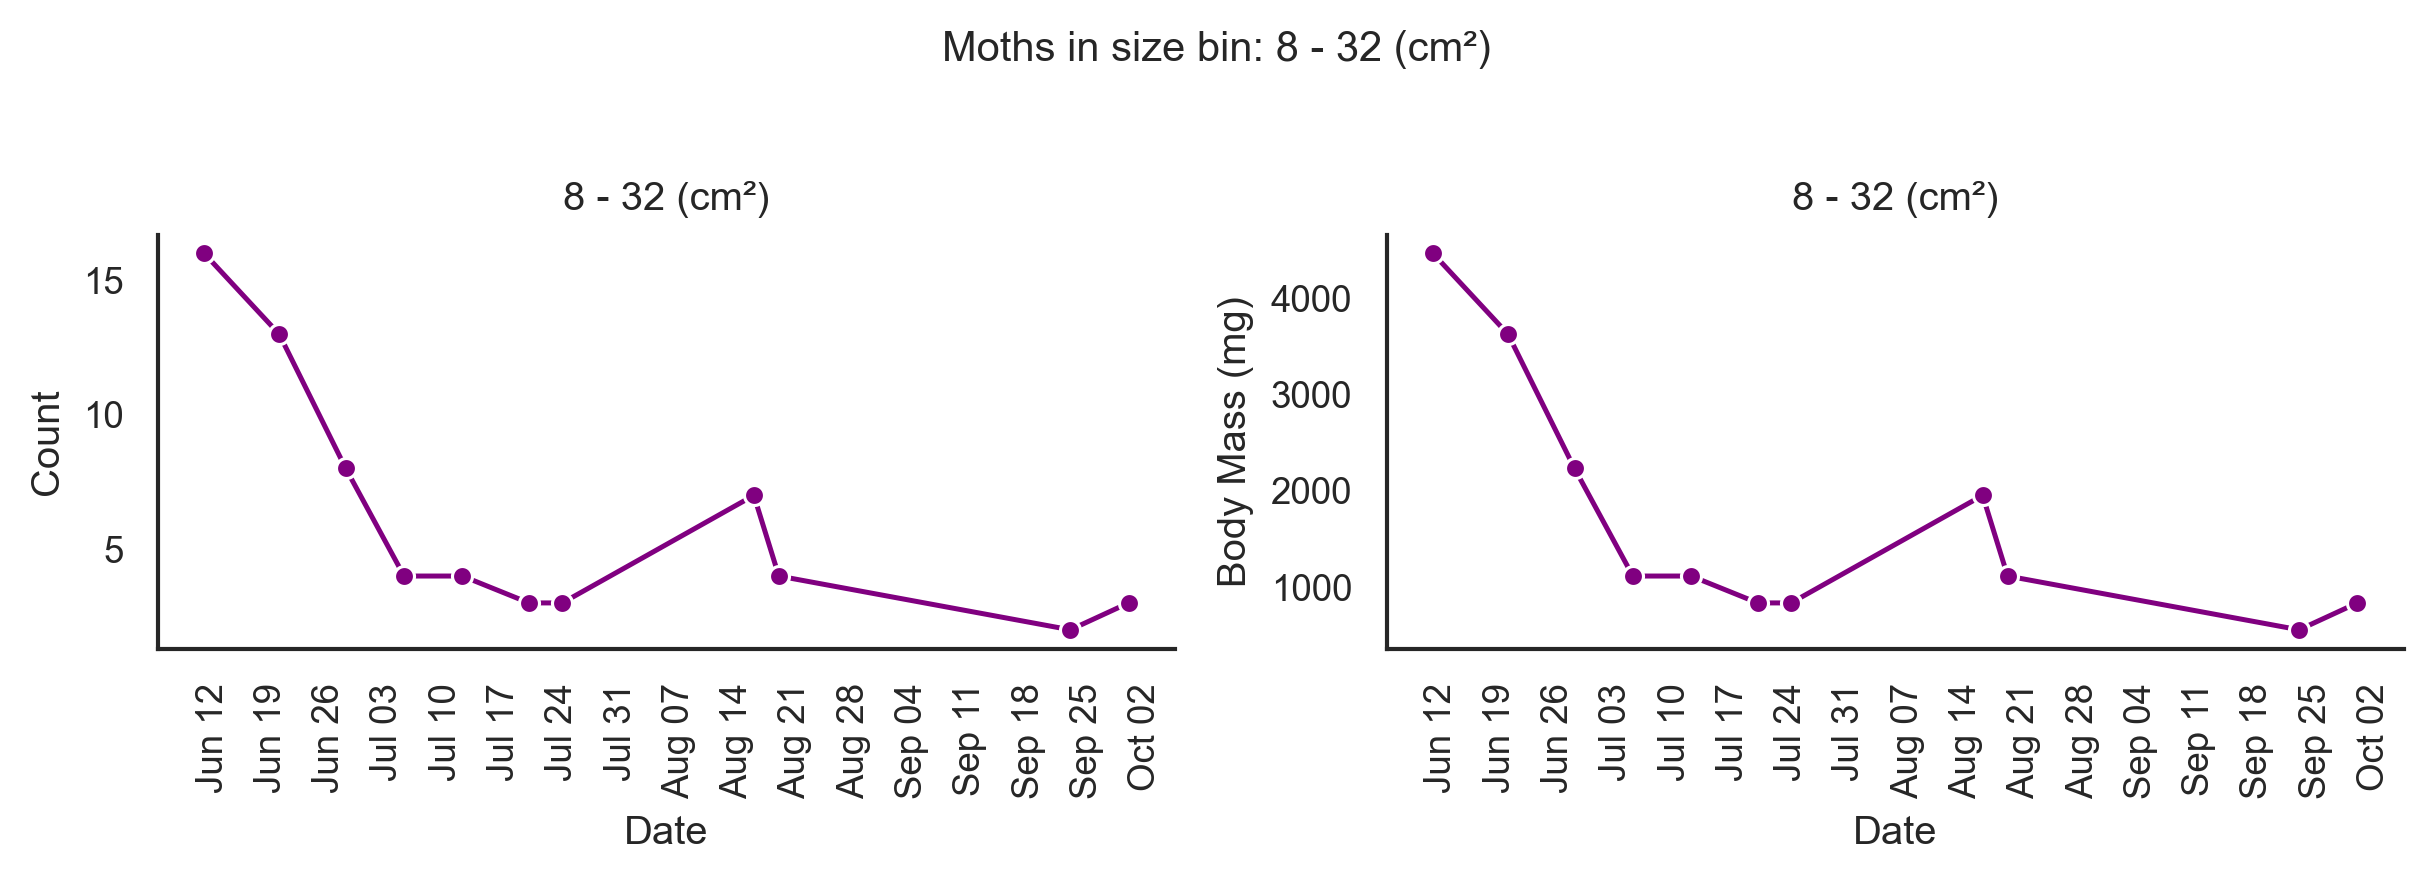

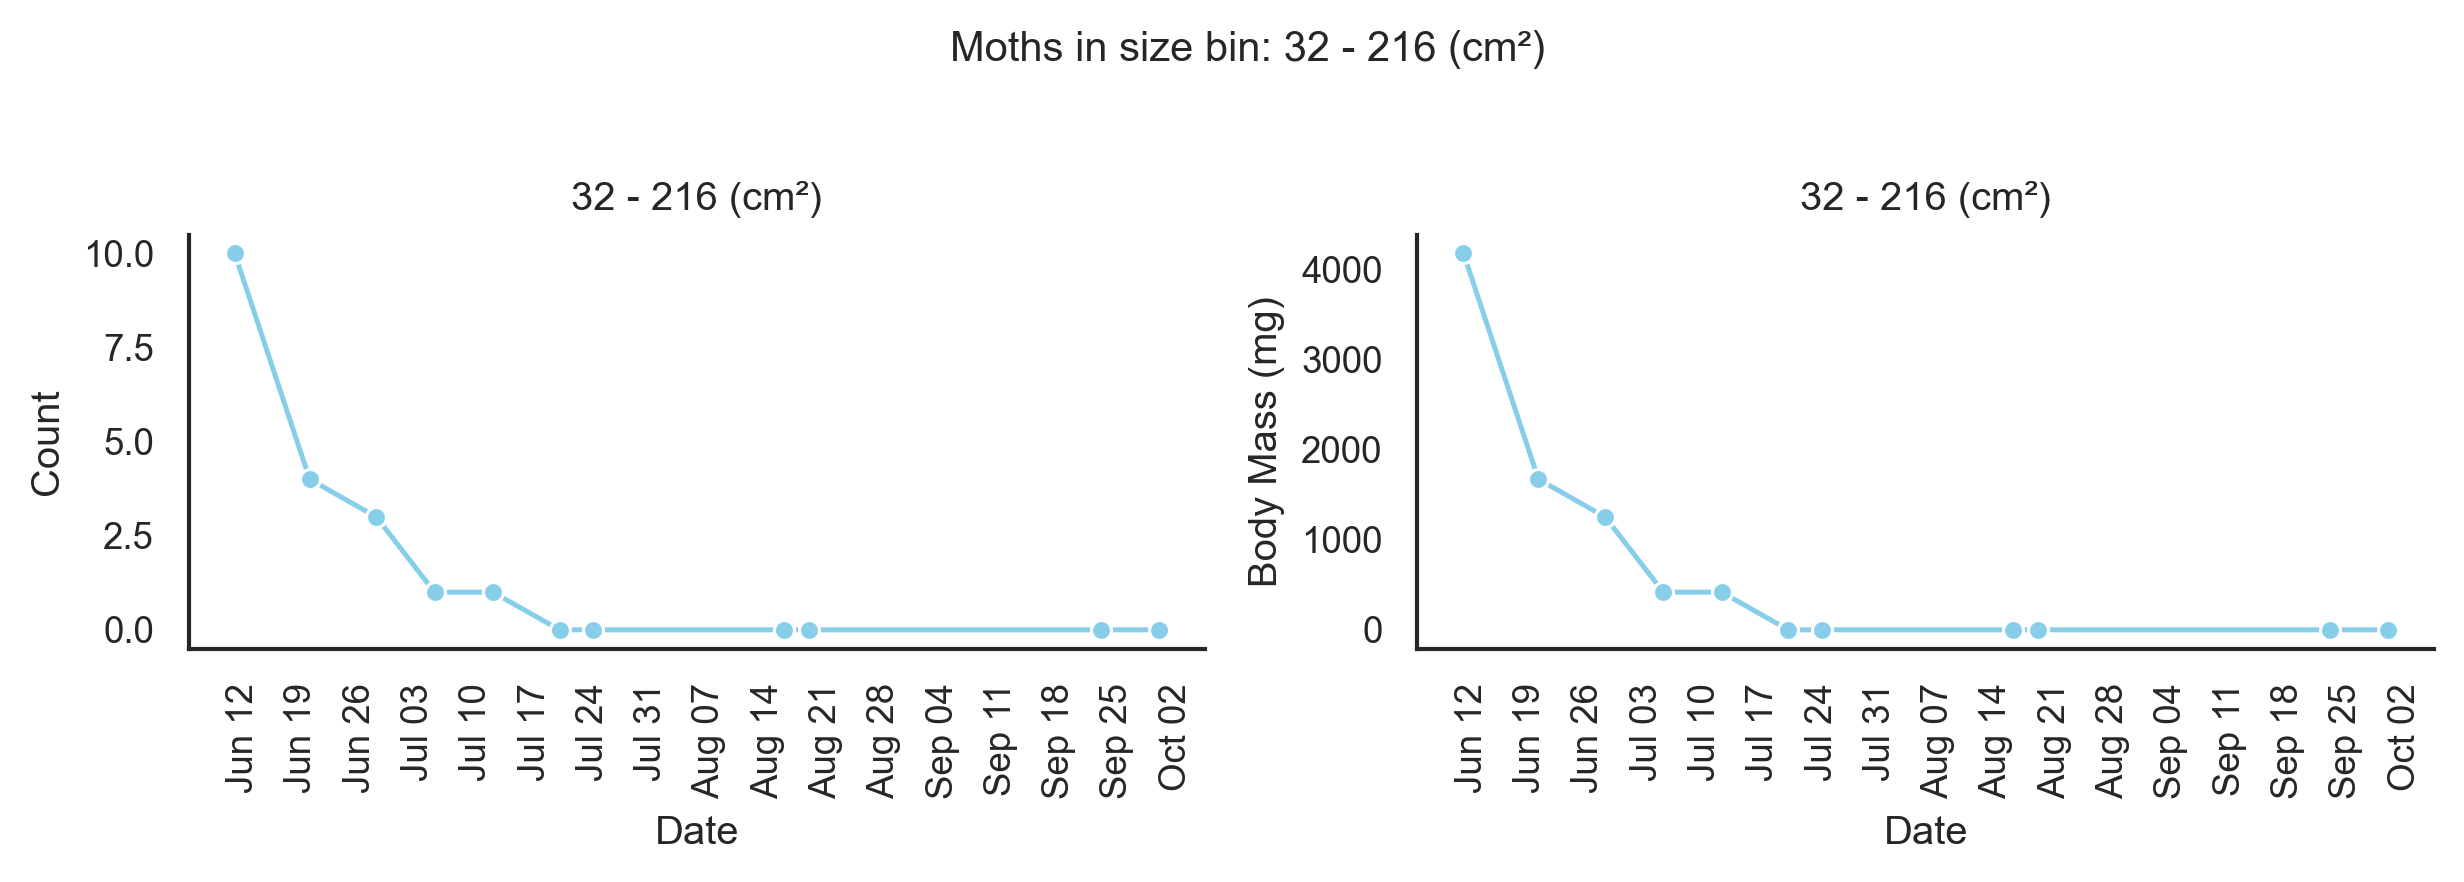

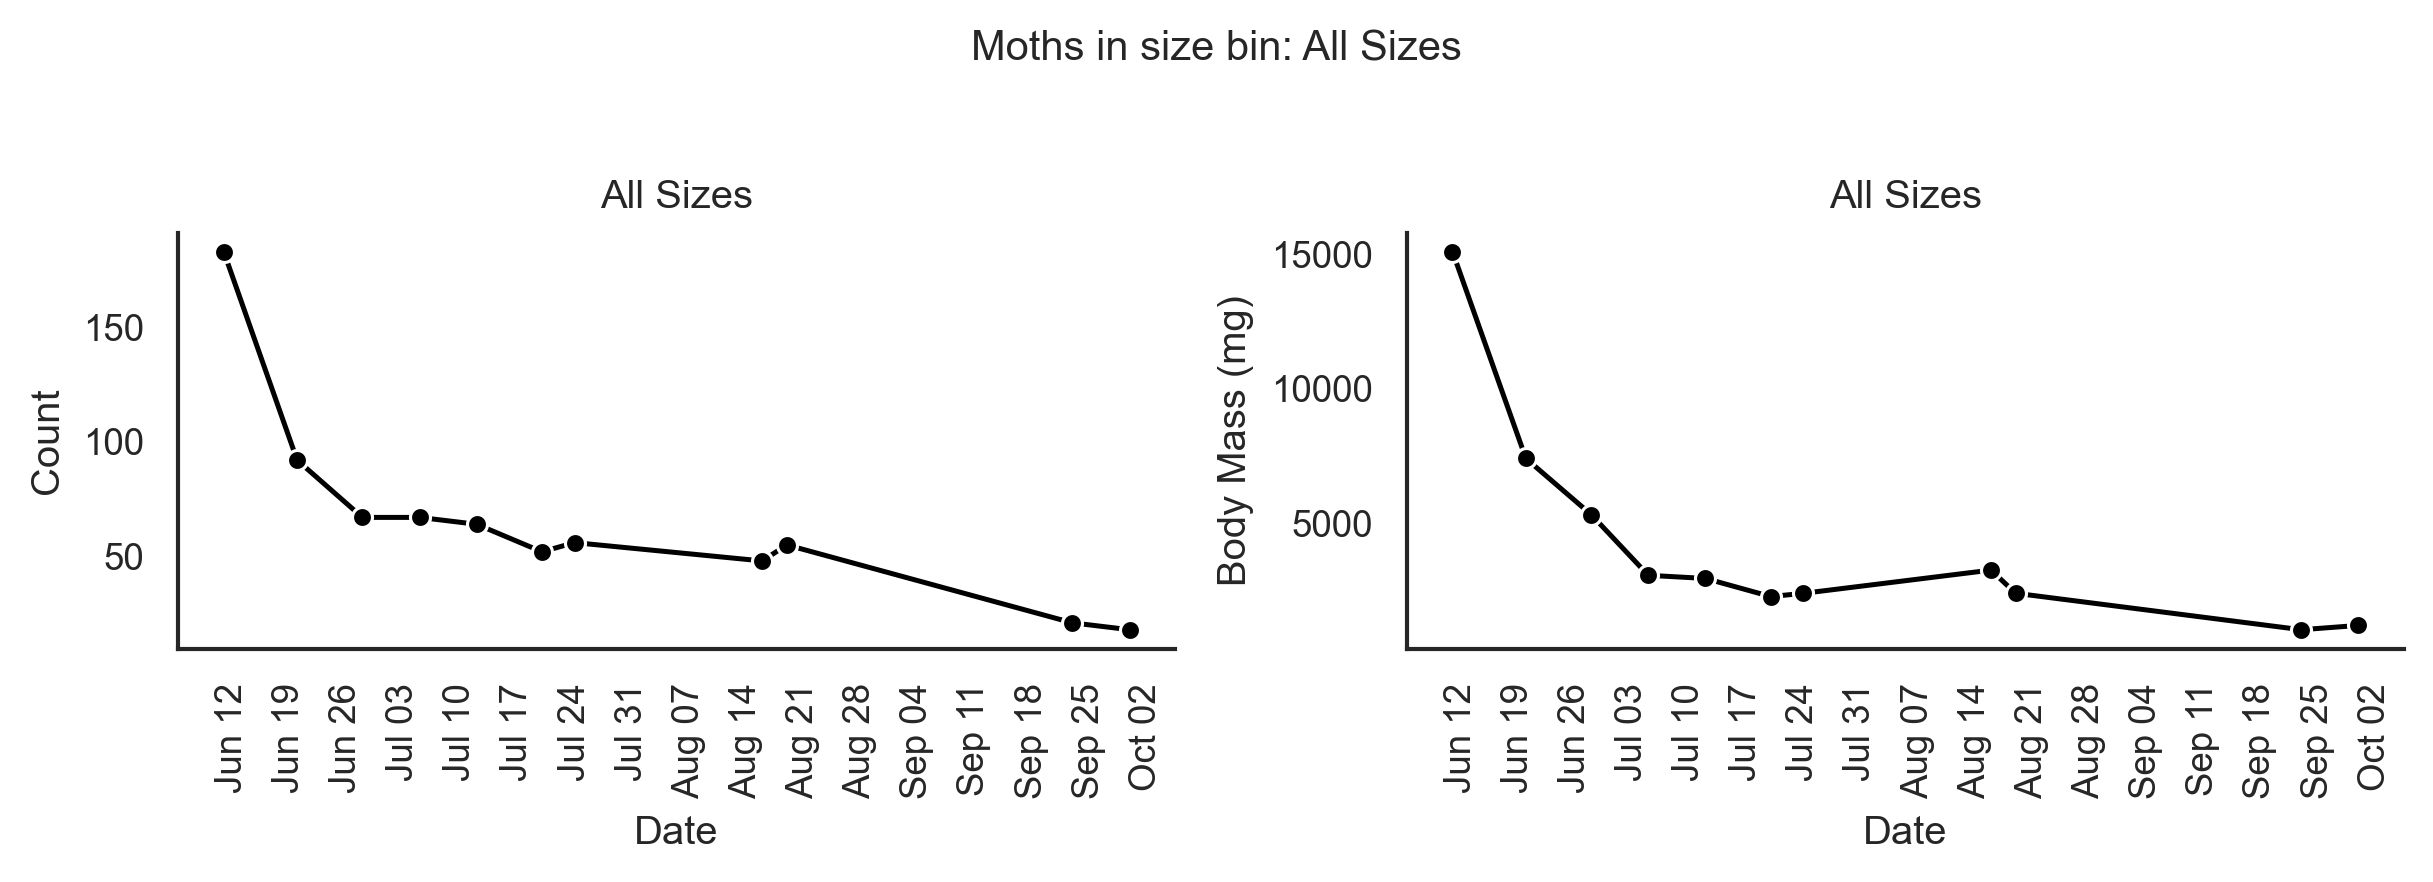

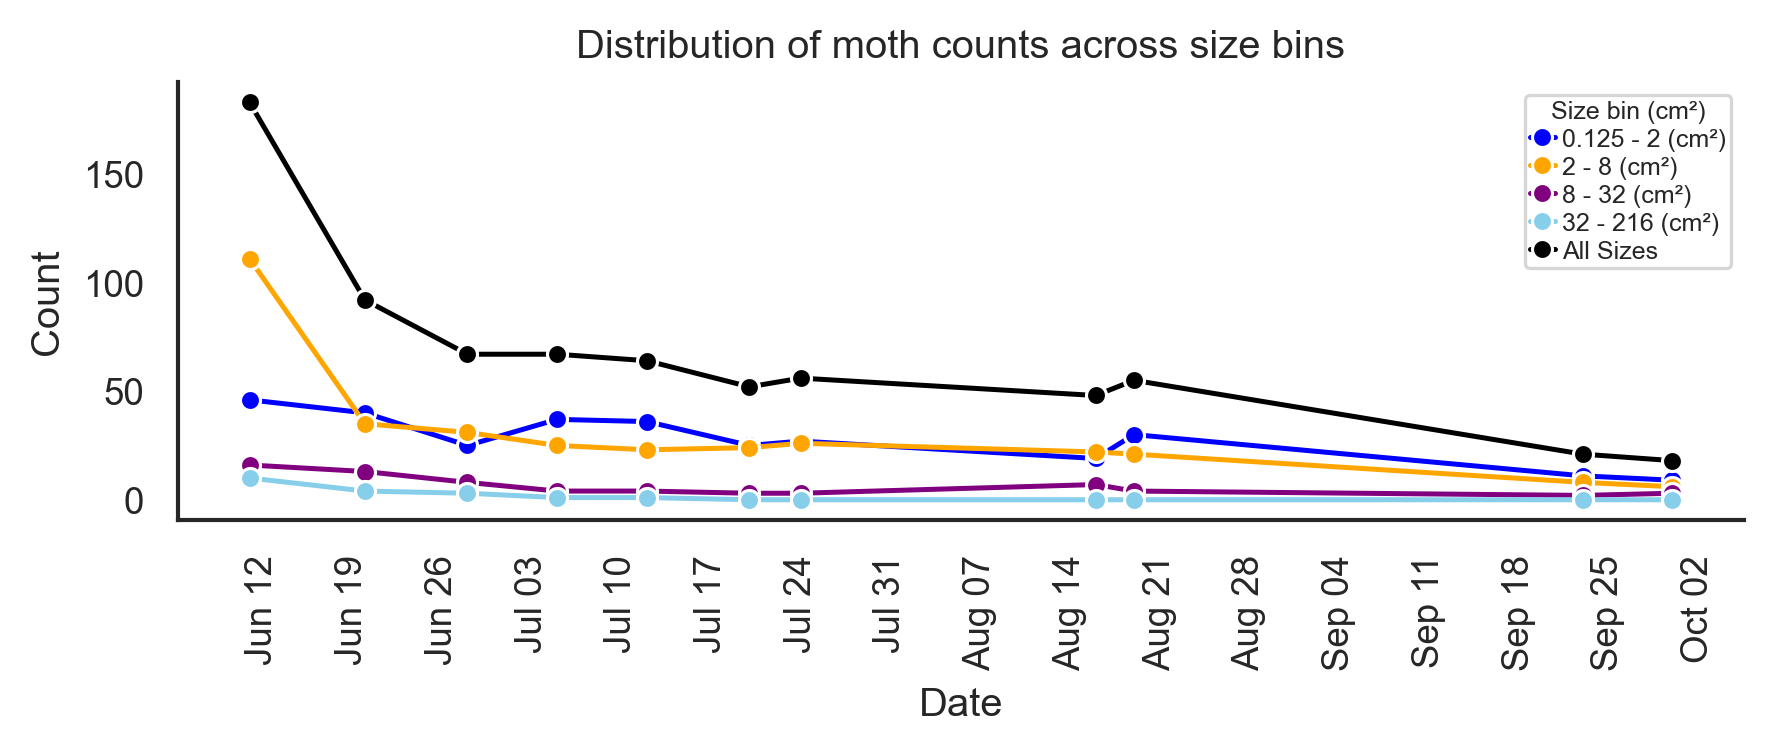

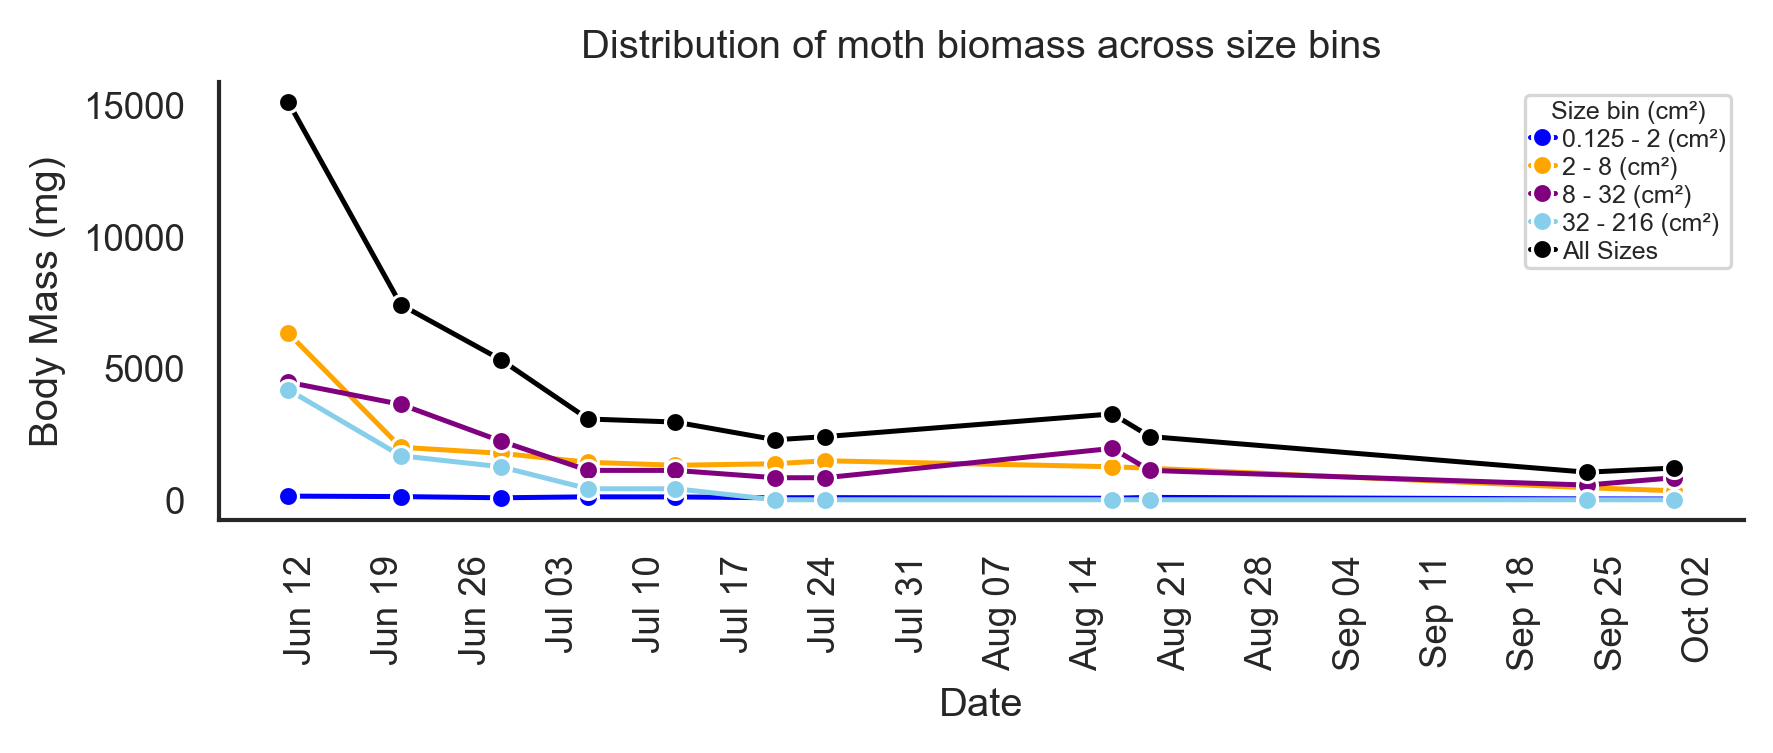

In [102]:
runtrends("2023", "WS5")

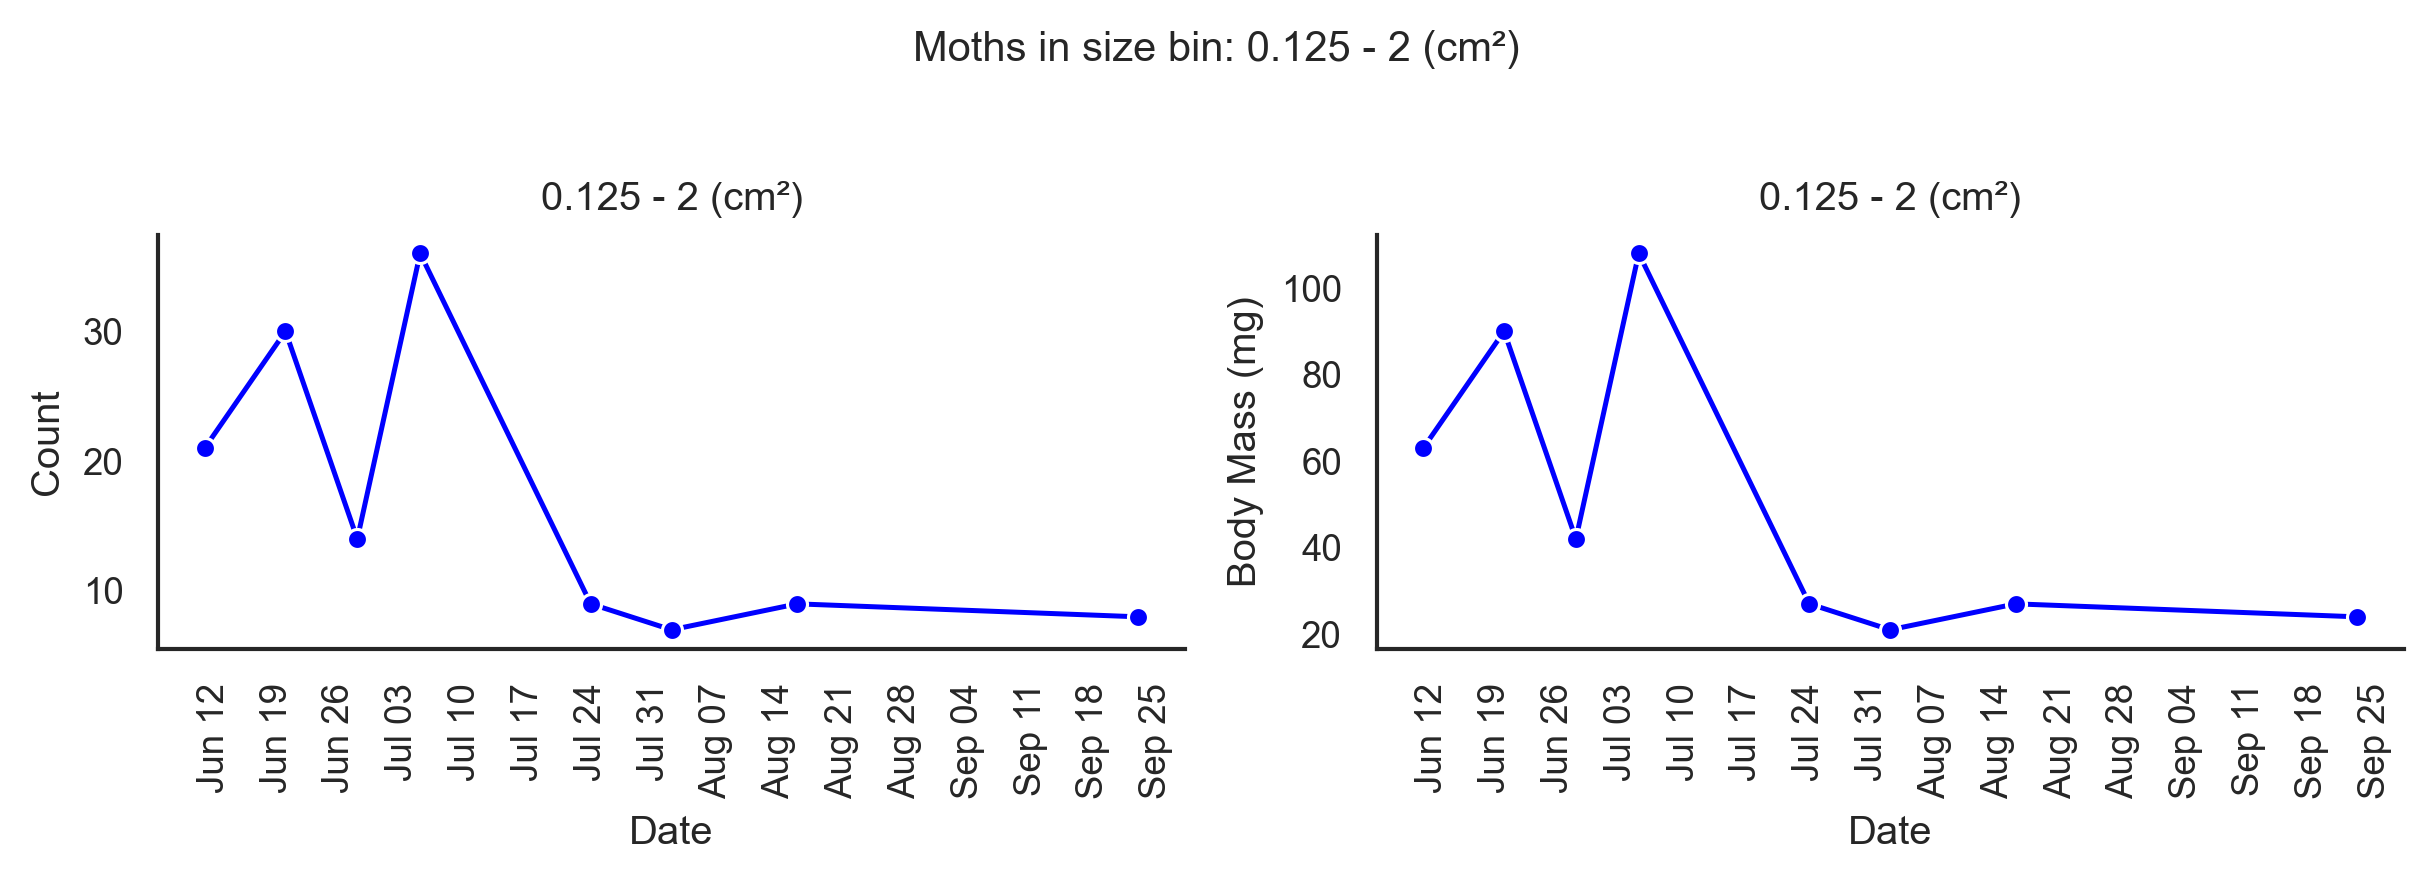

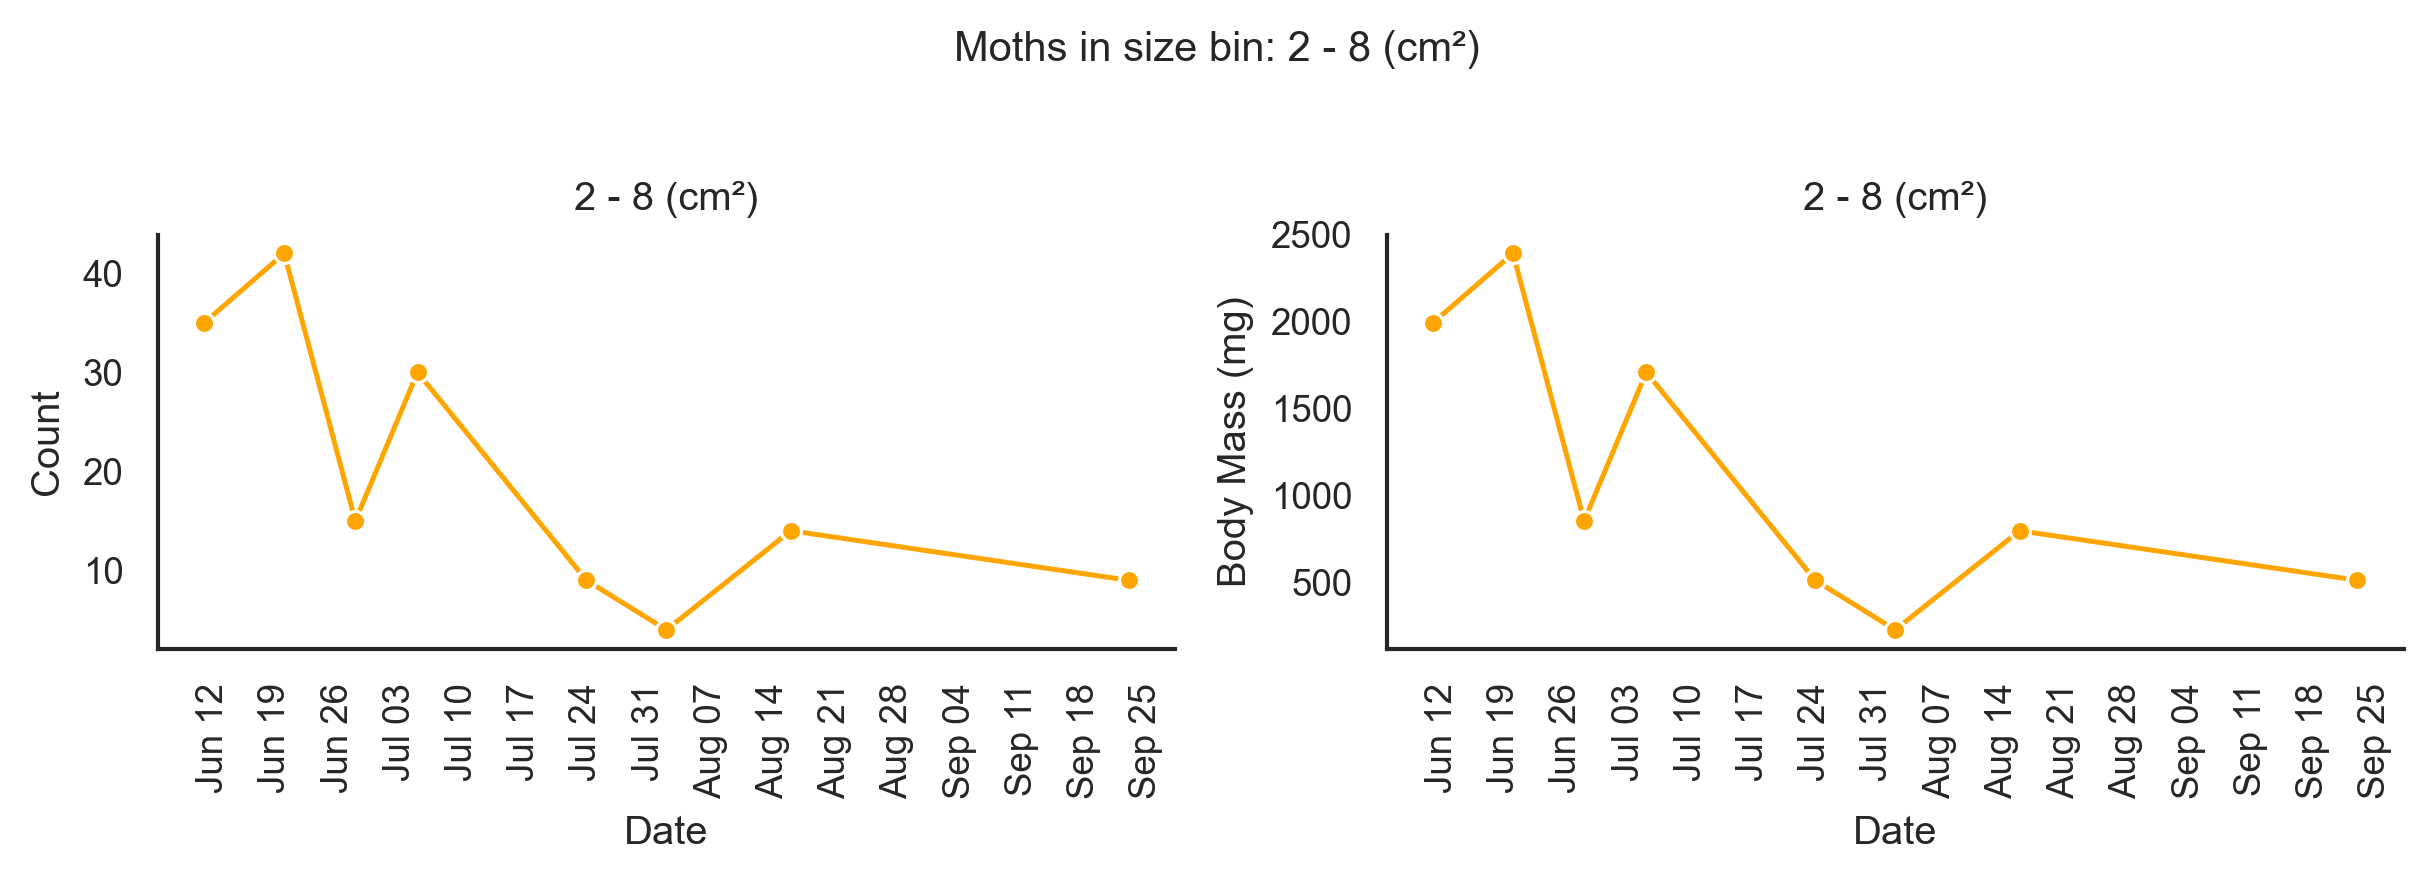

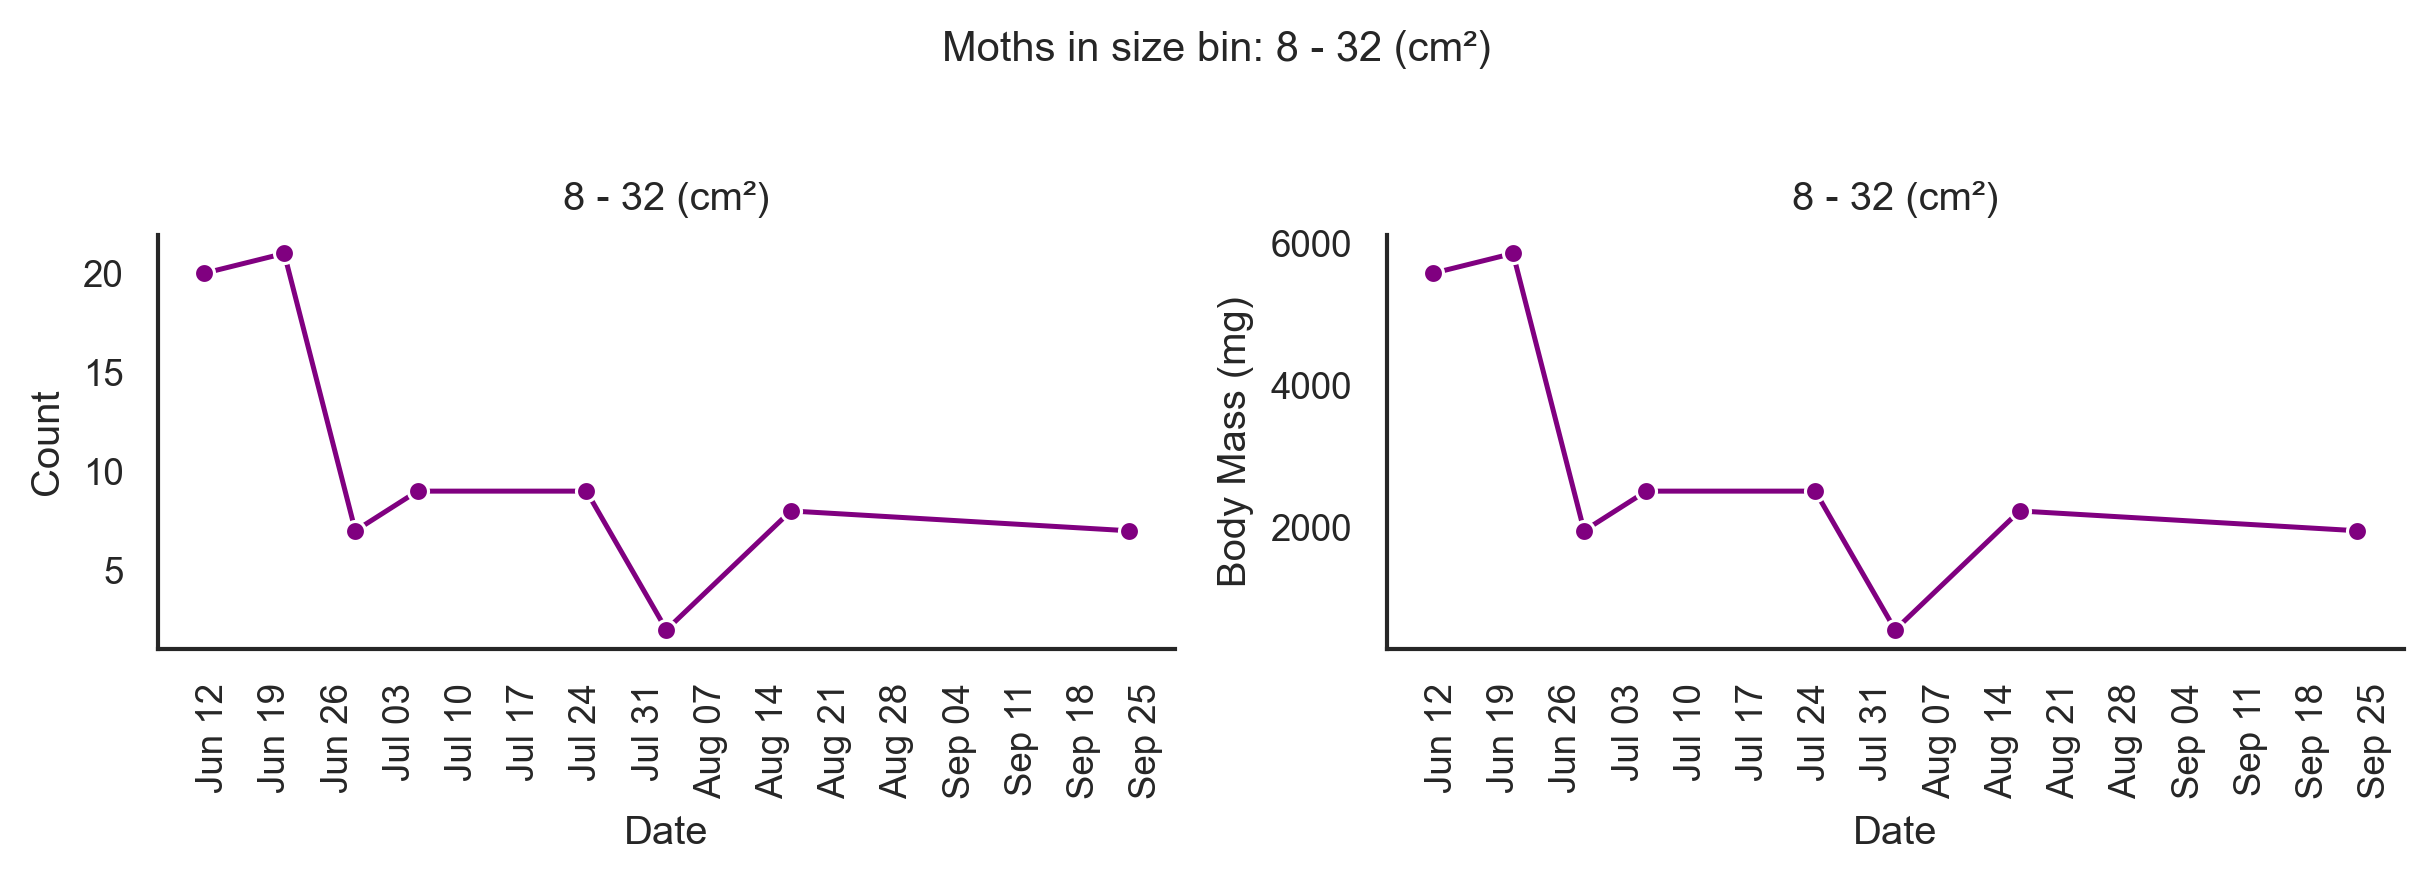

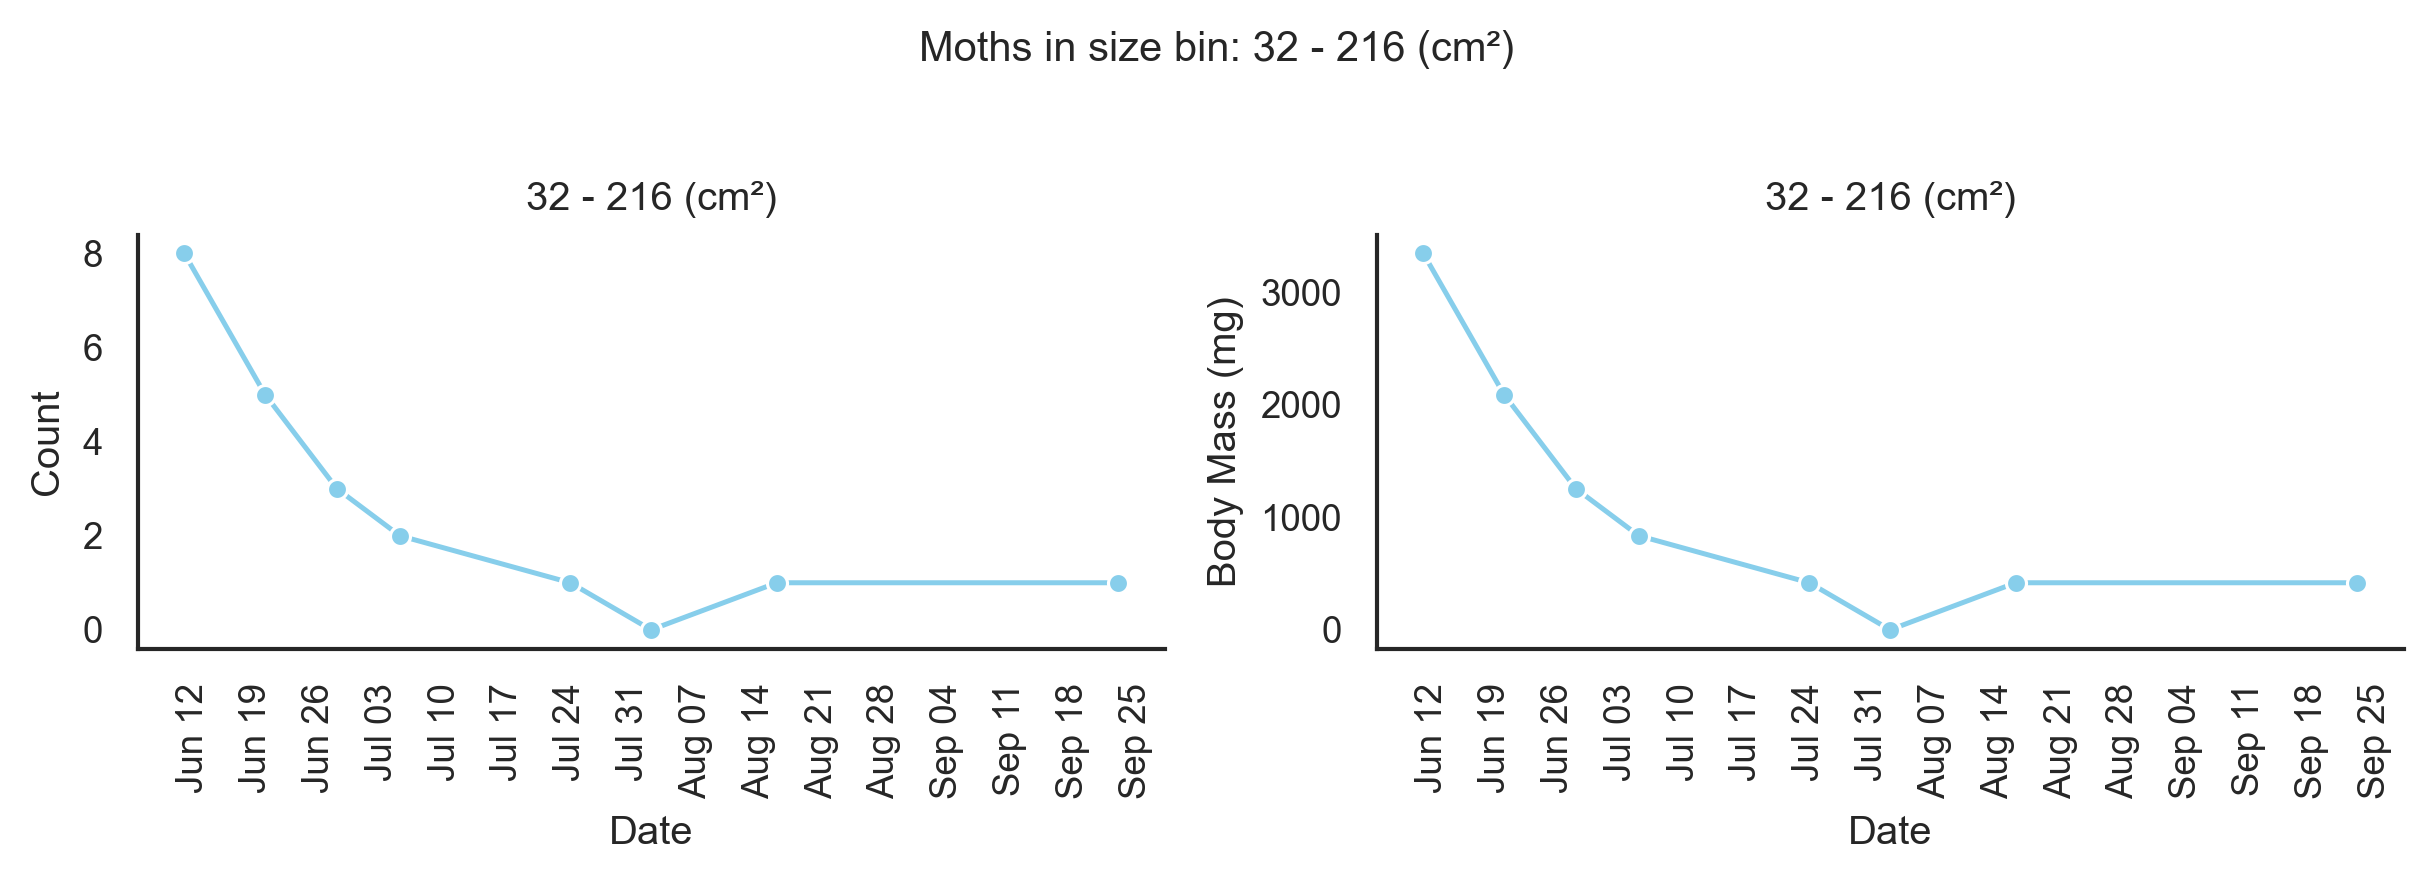

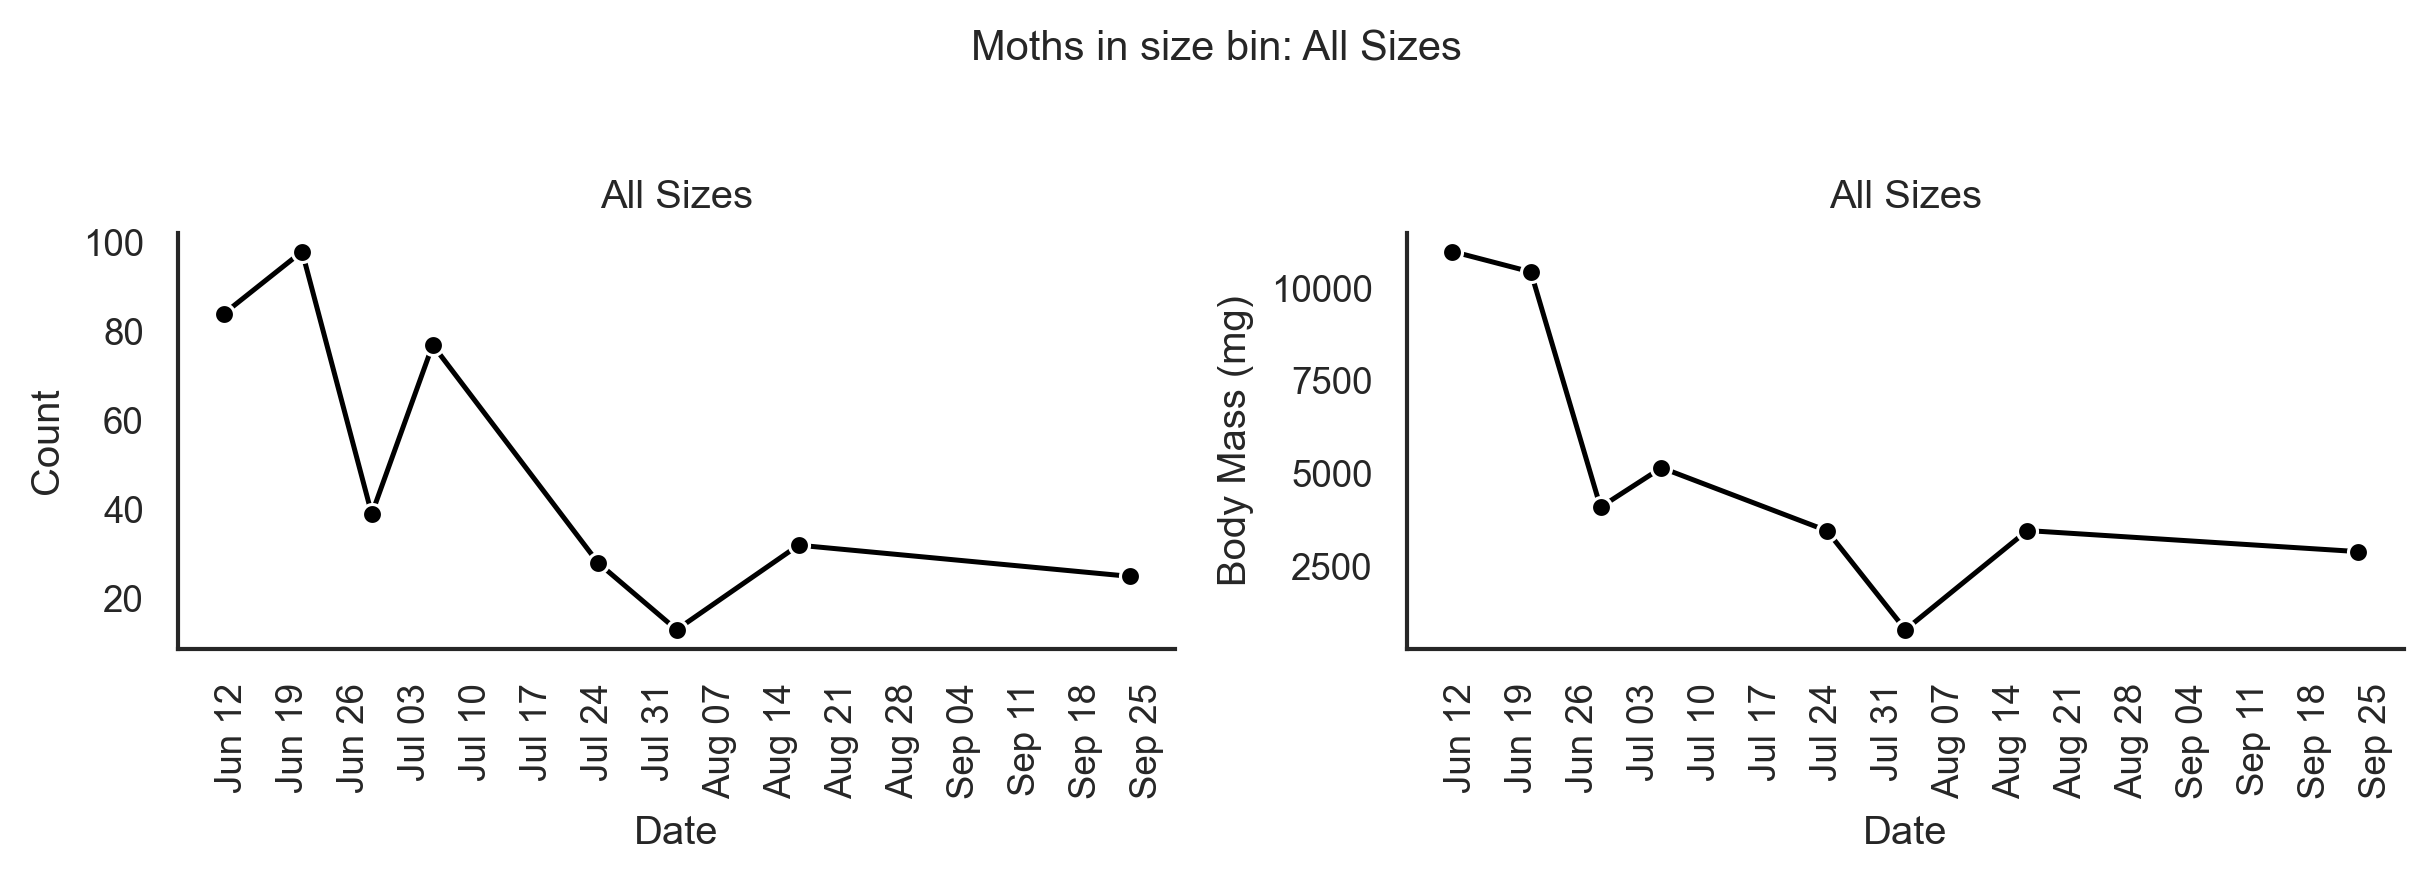

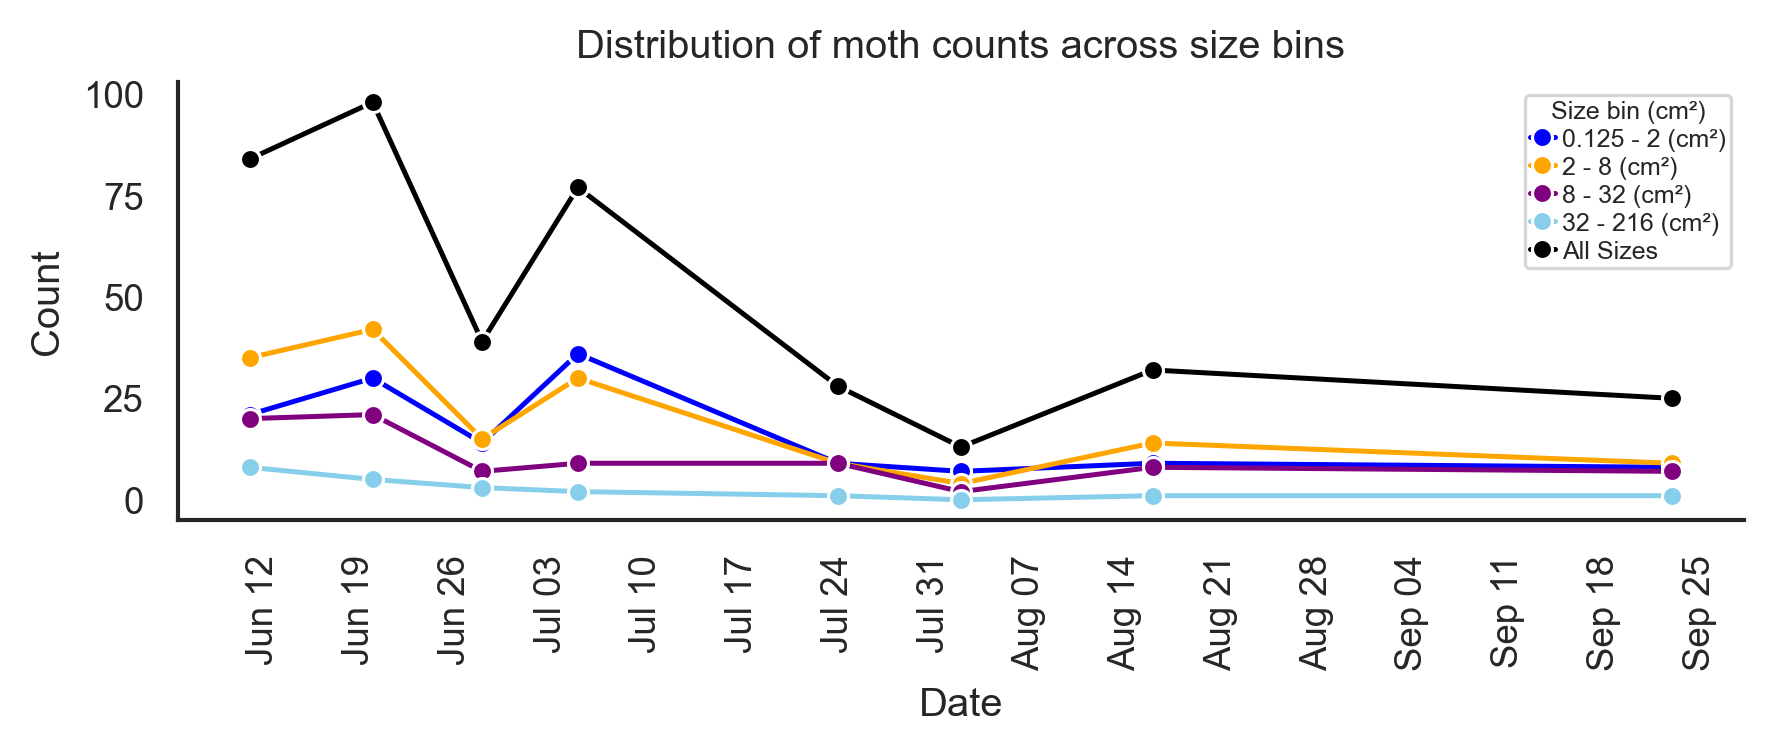

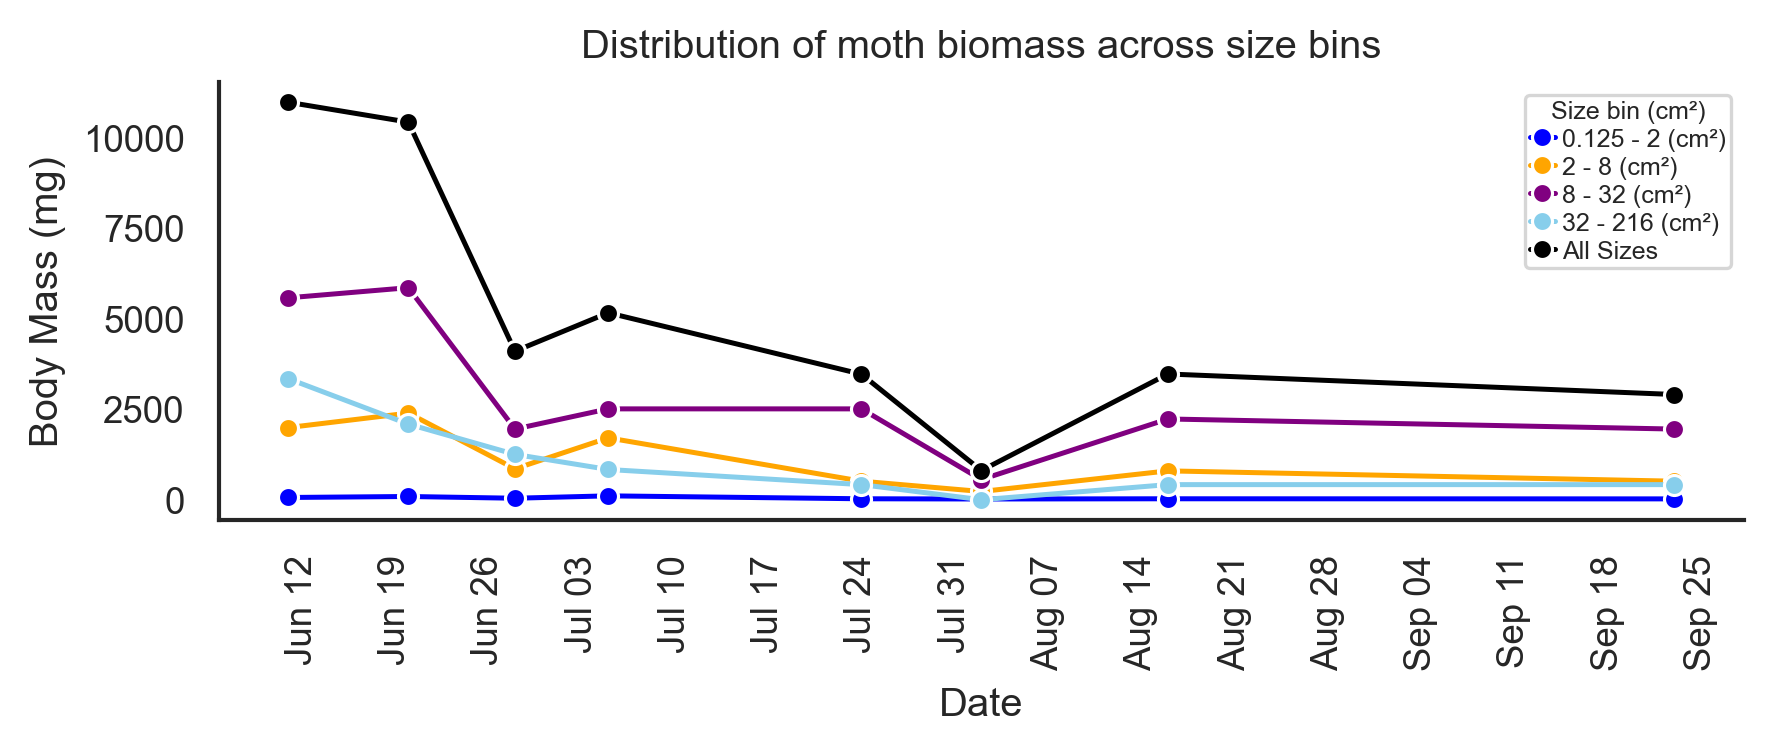

In [103]:
runtrends("2023", "WS6up")

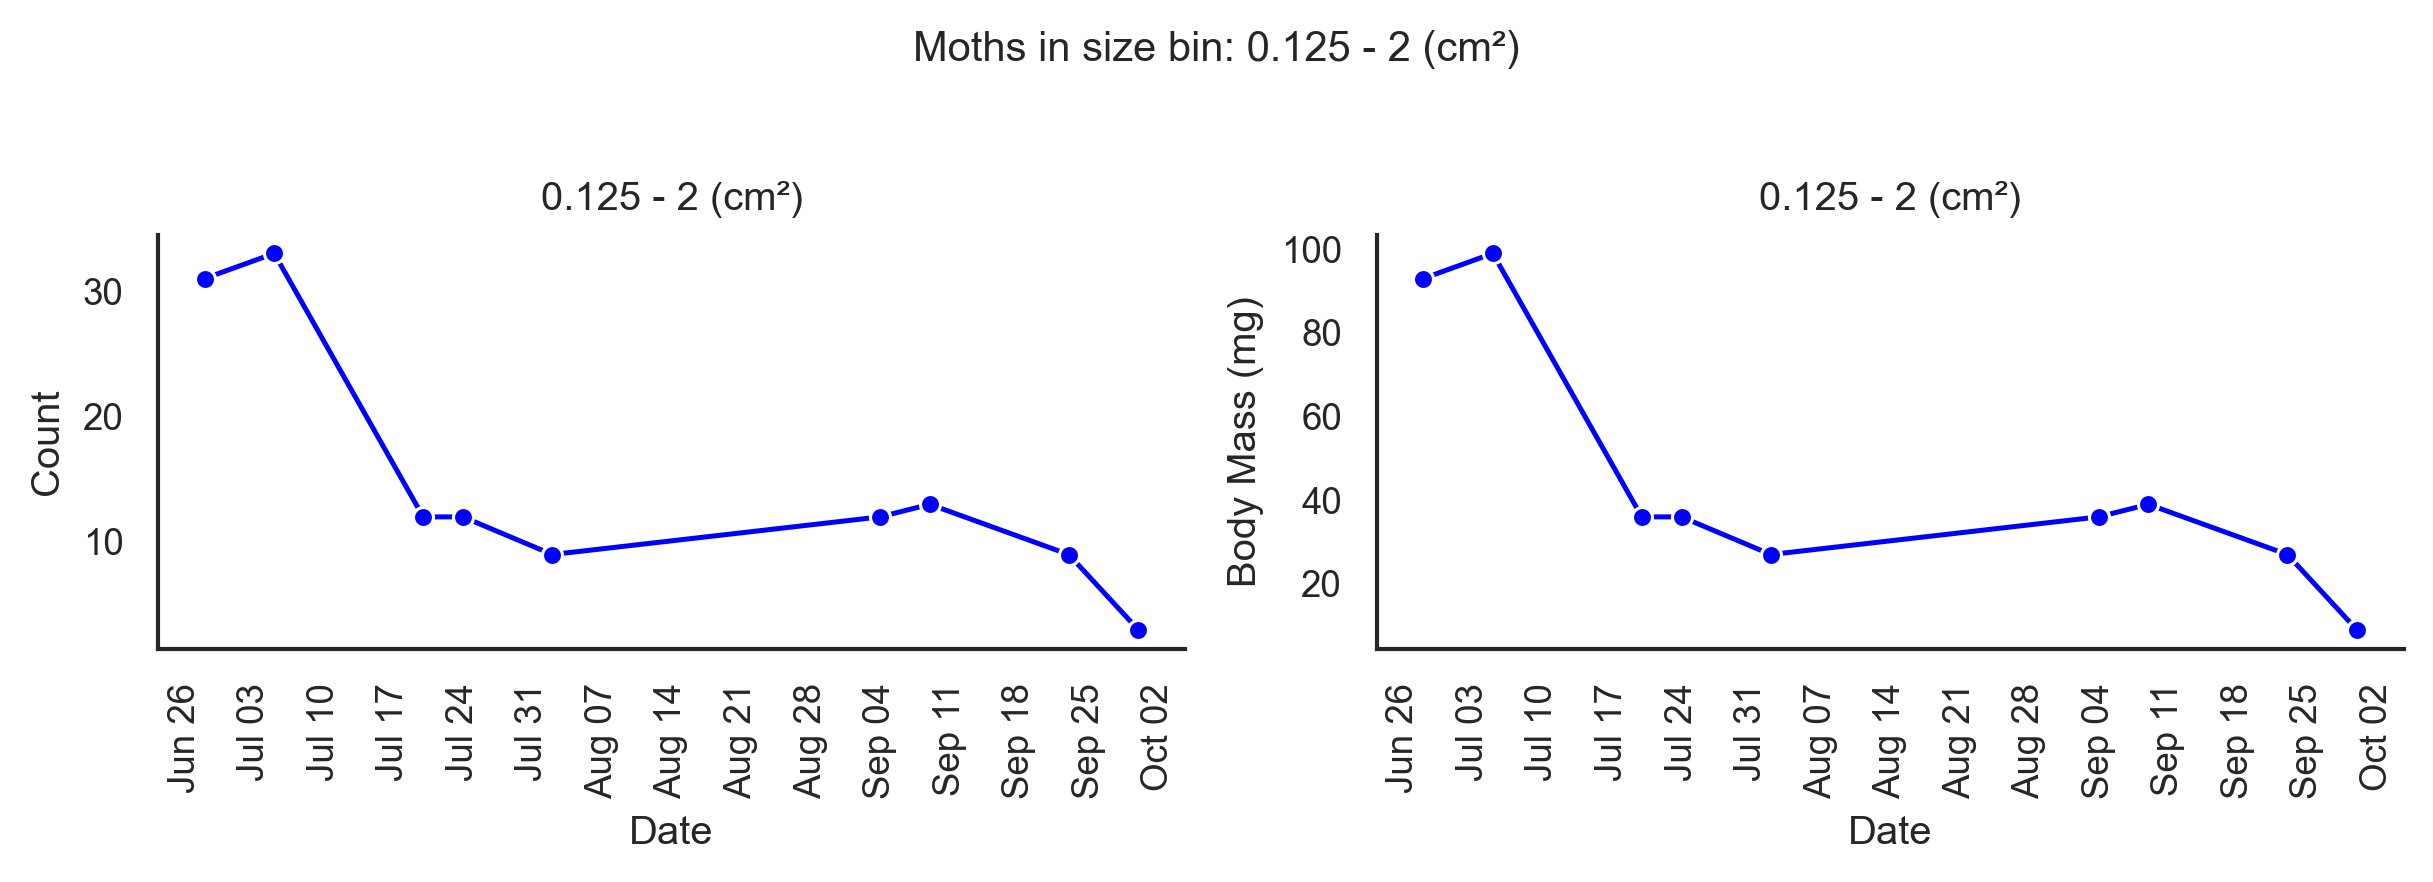

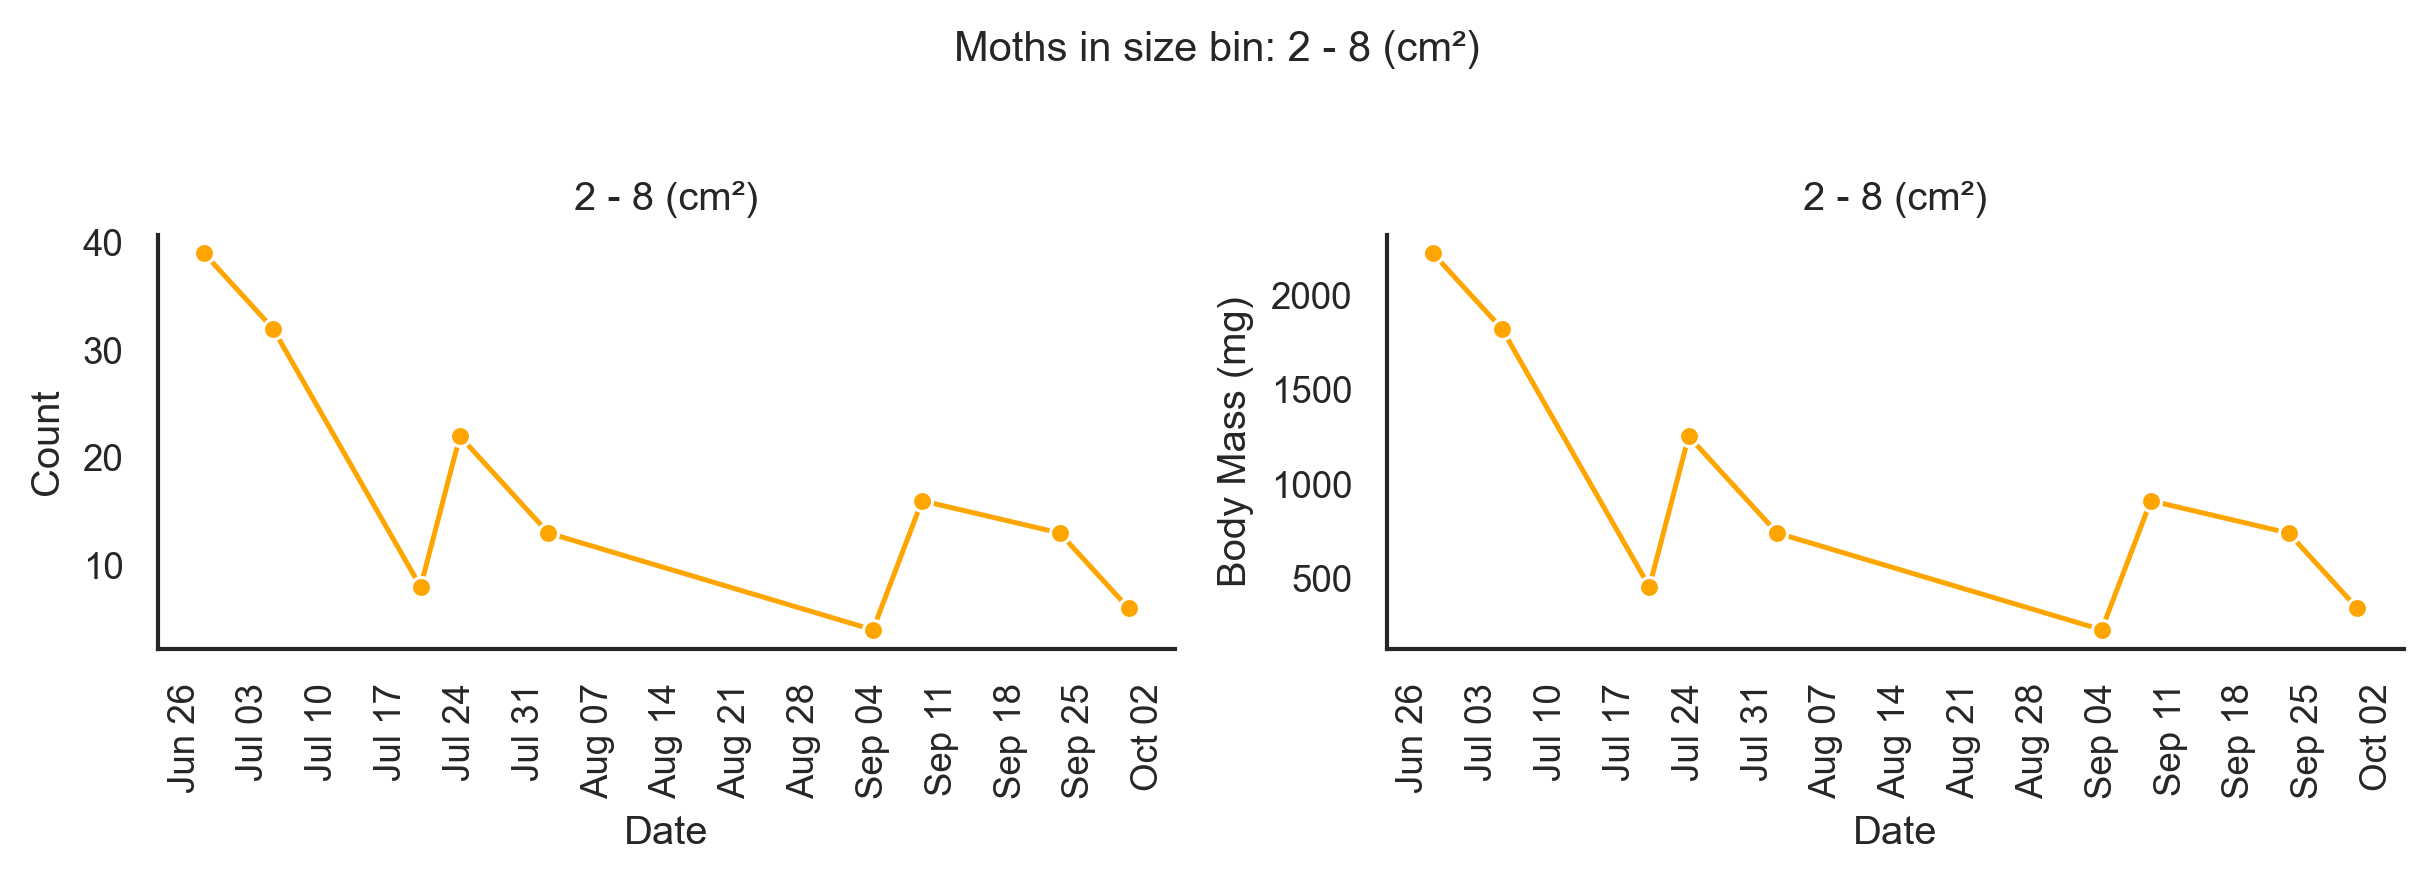

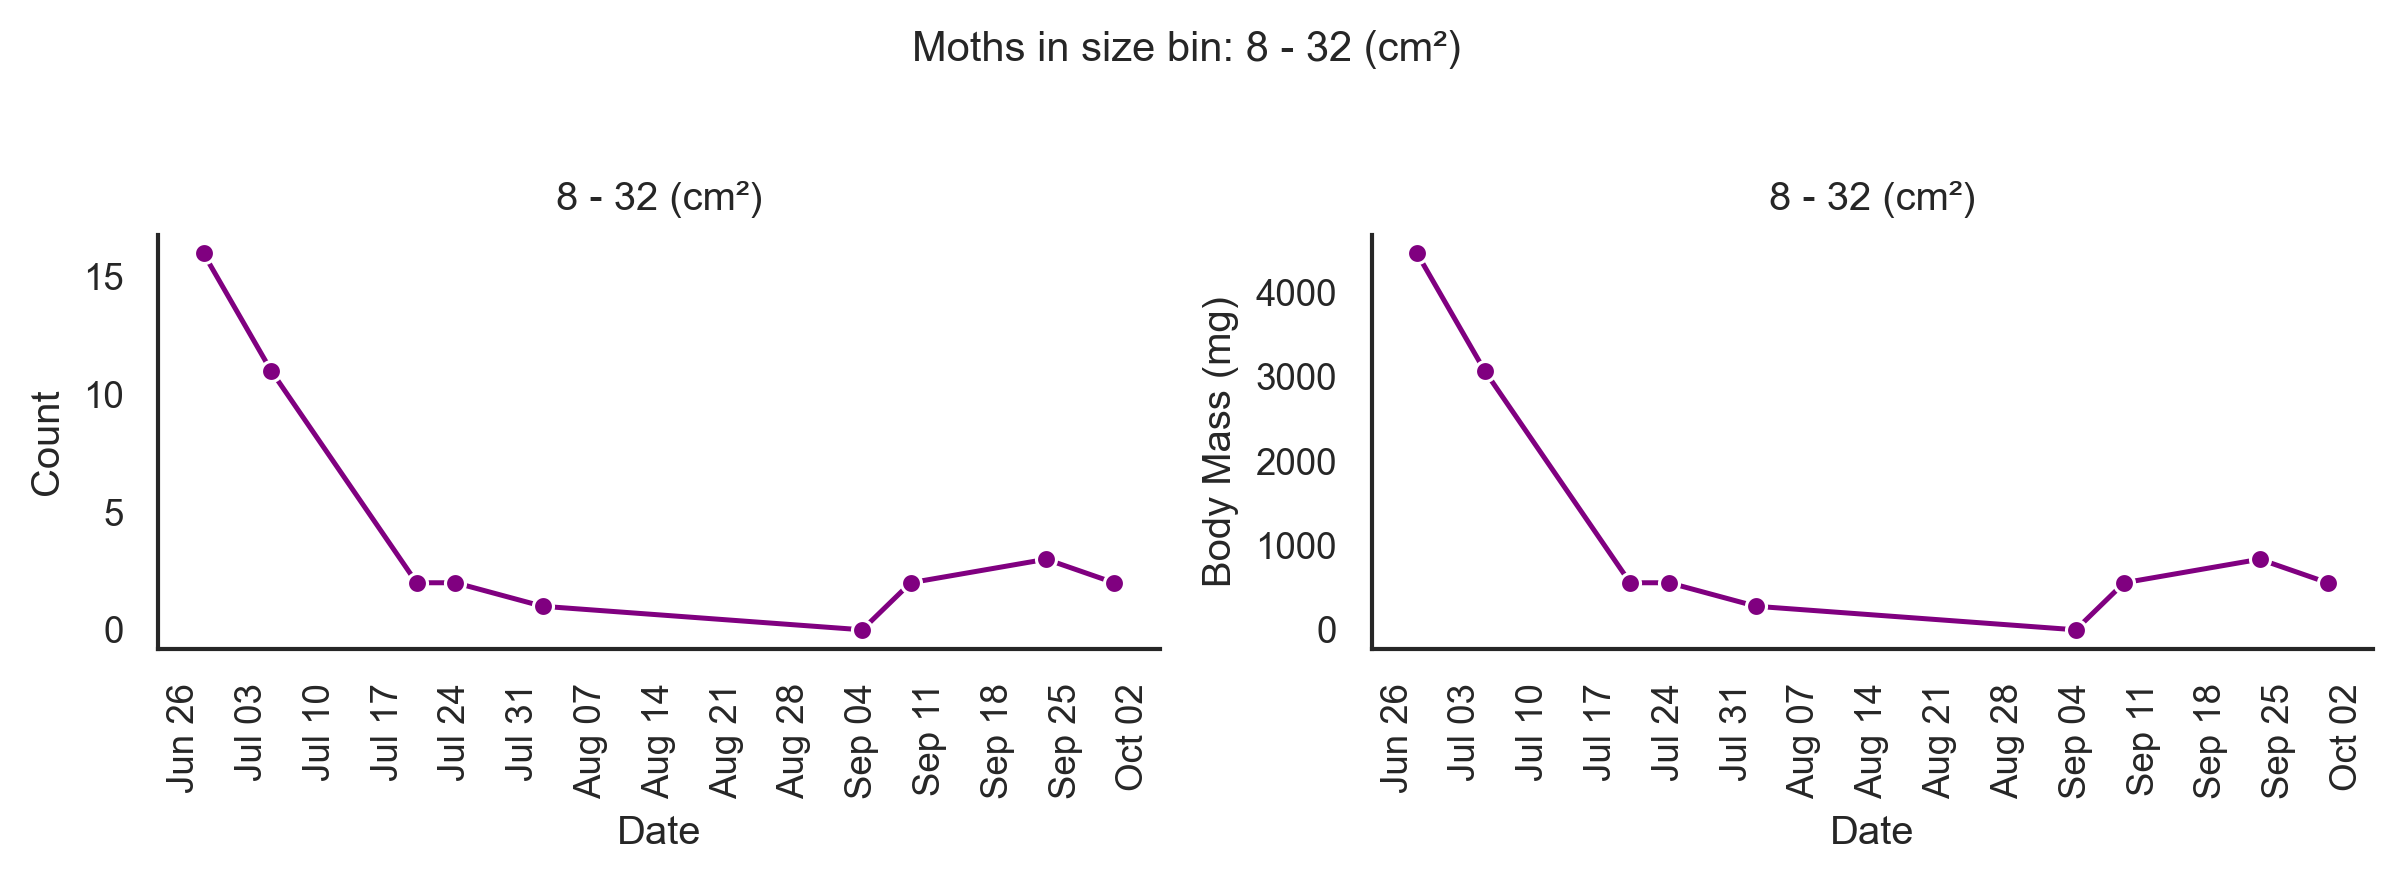

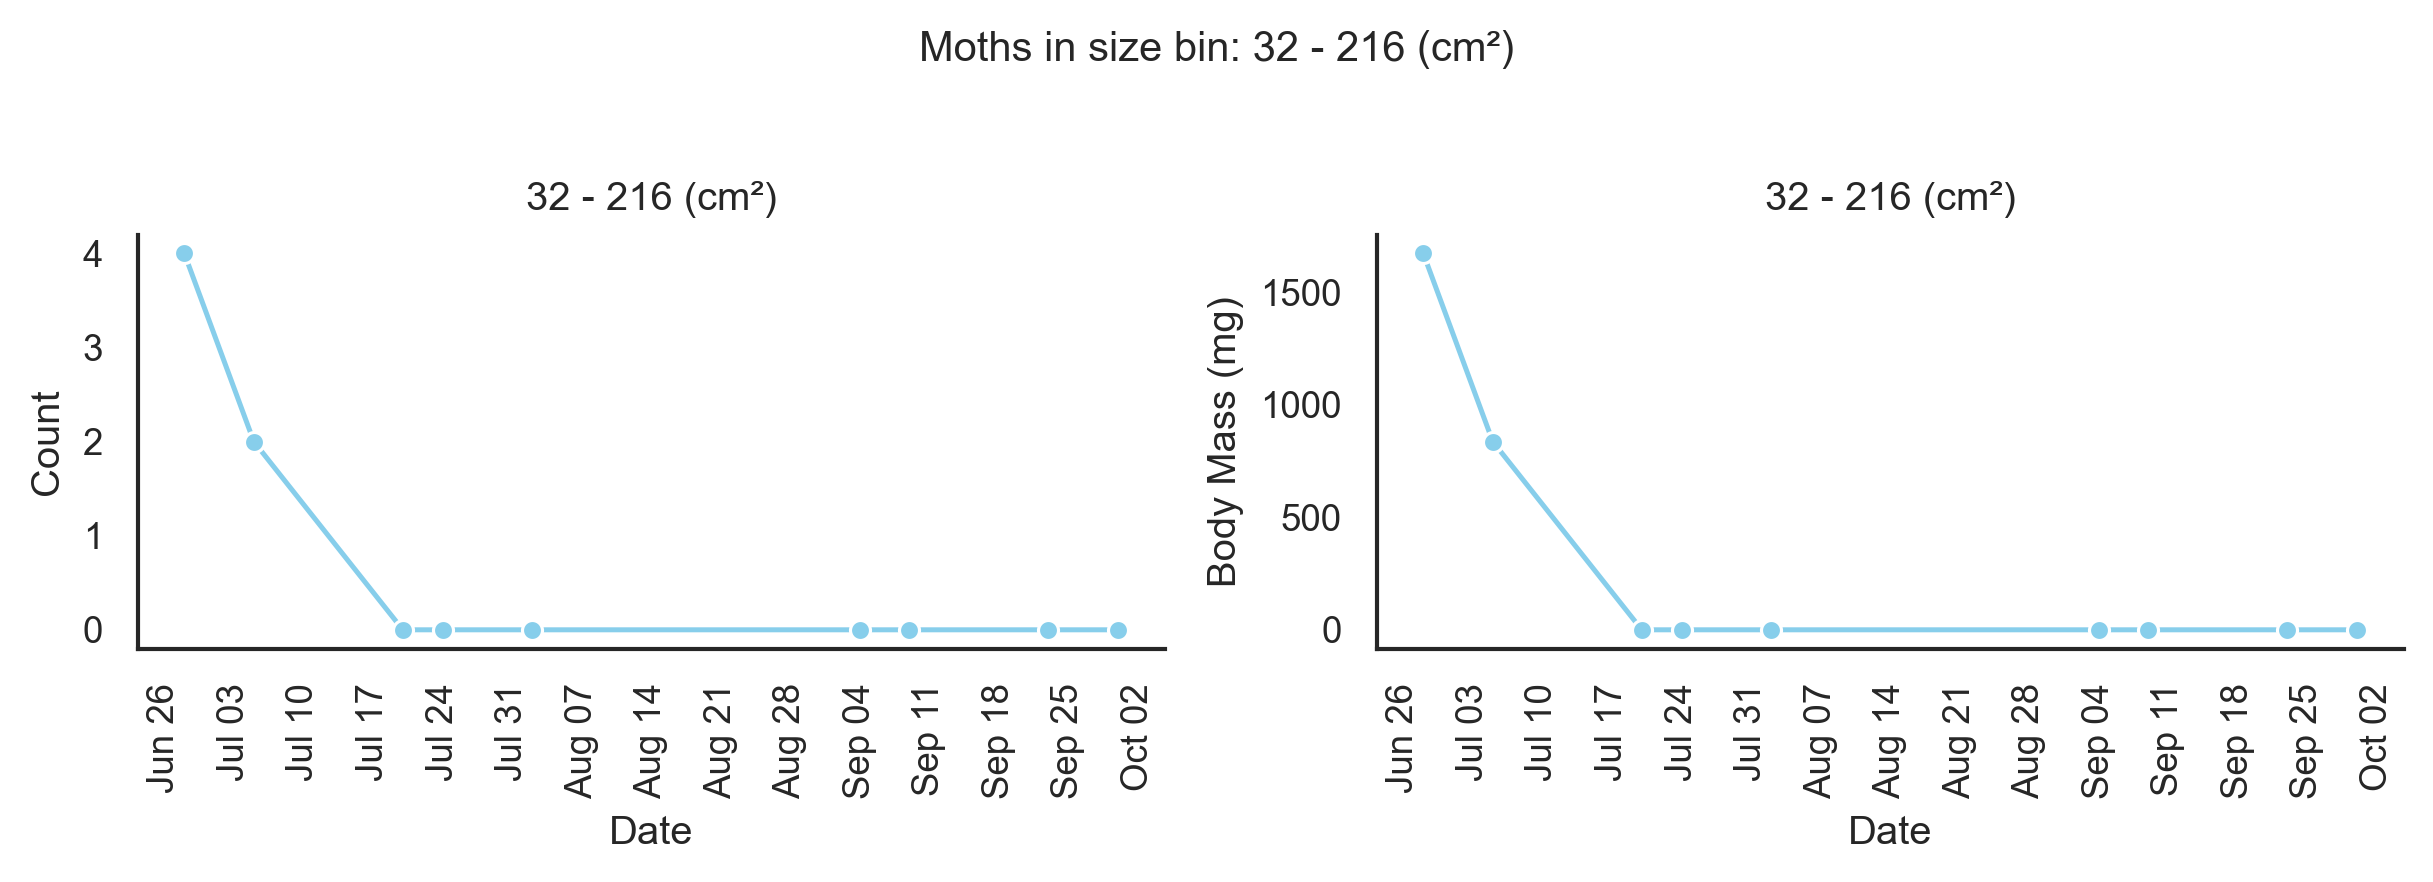

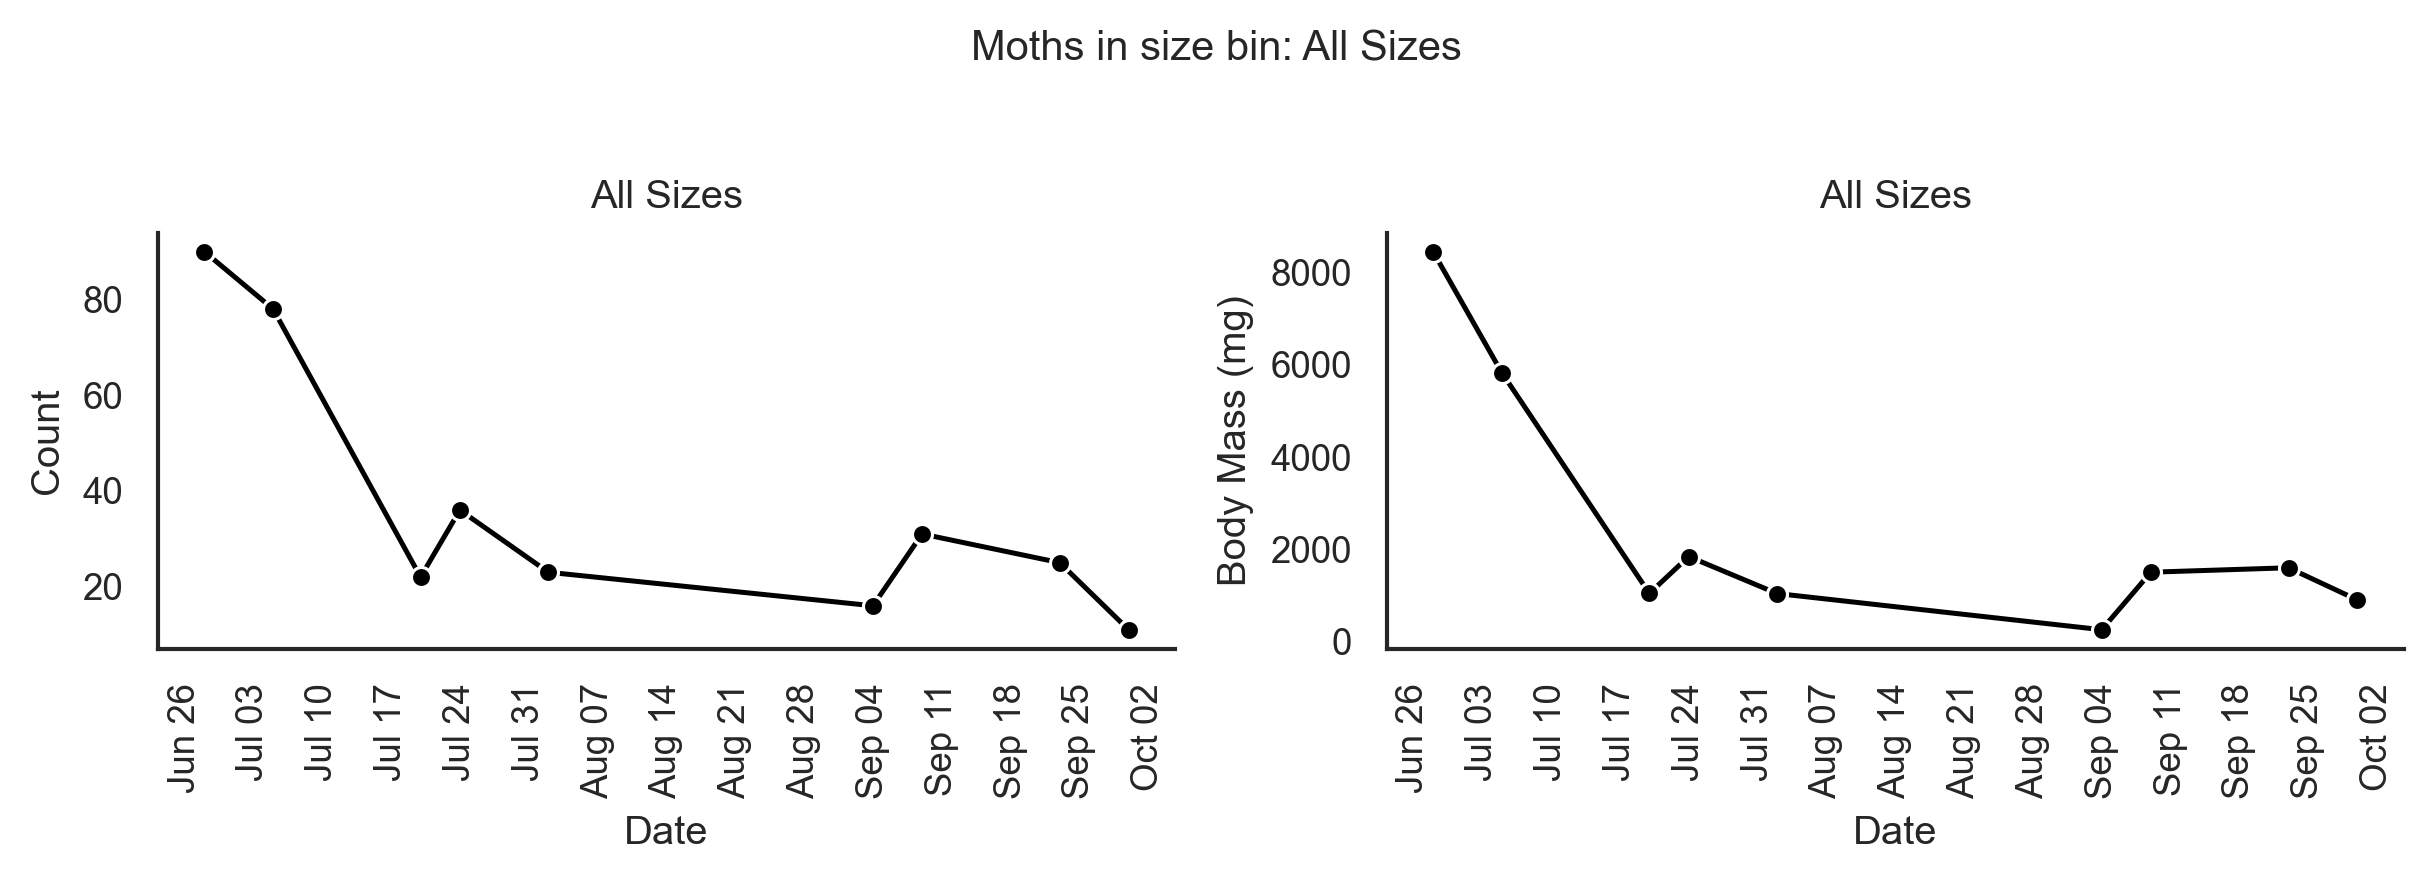

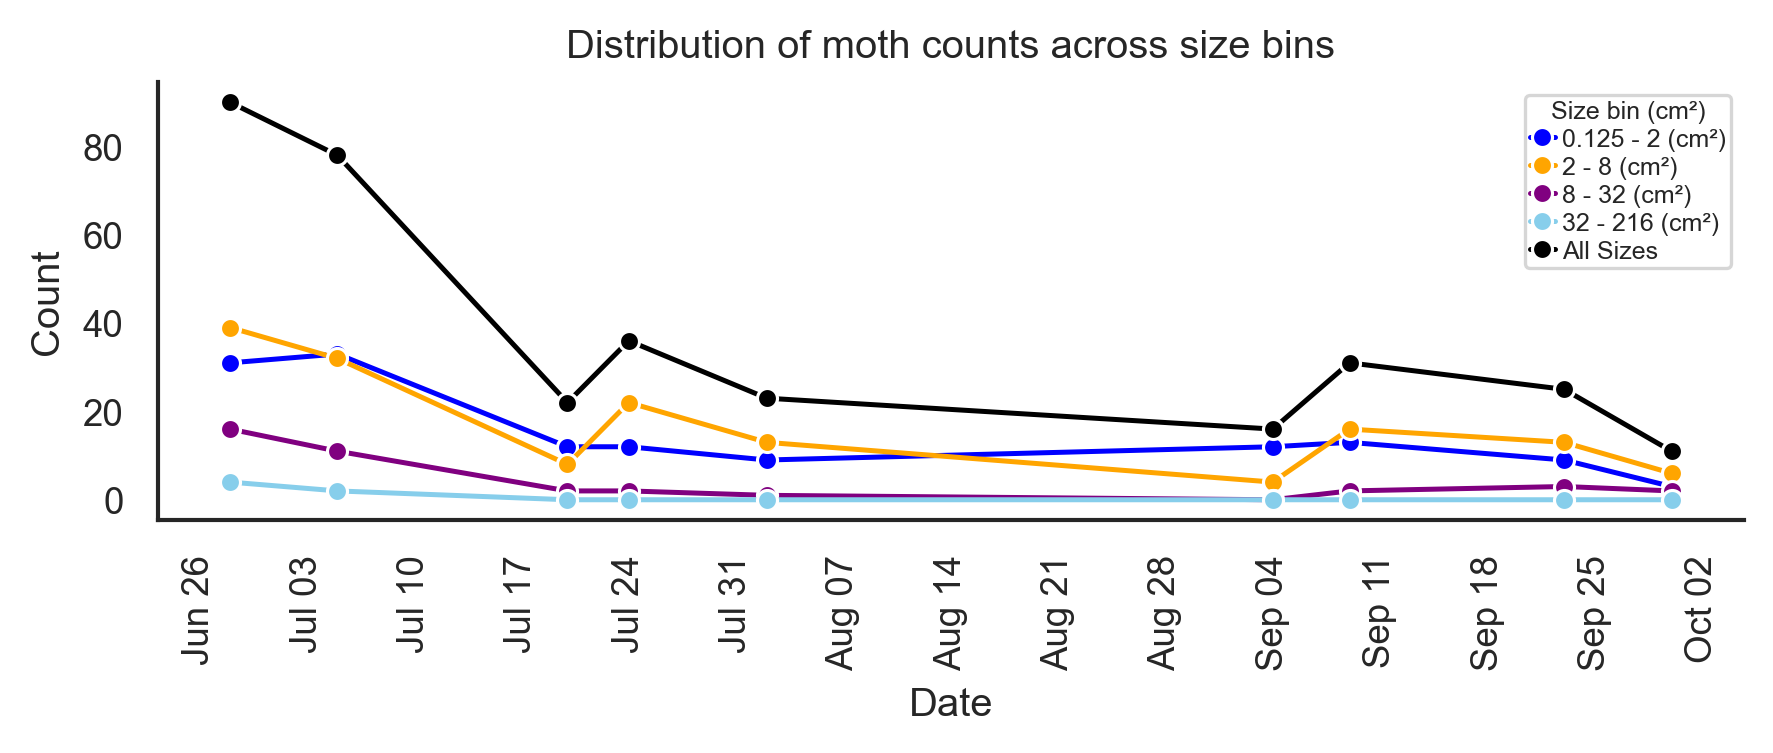

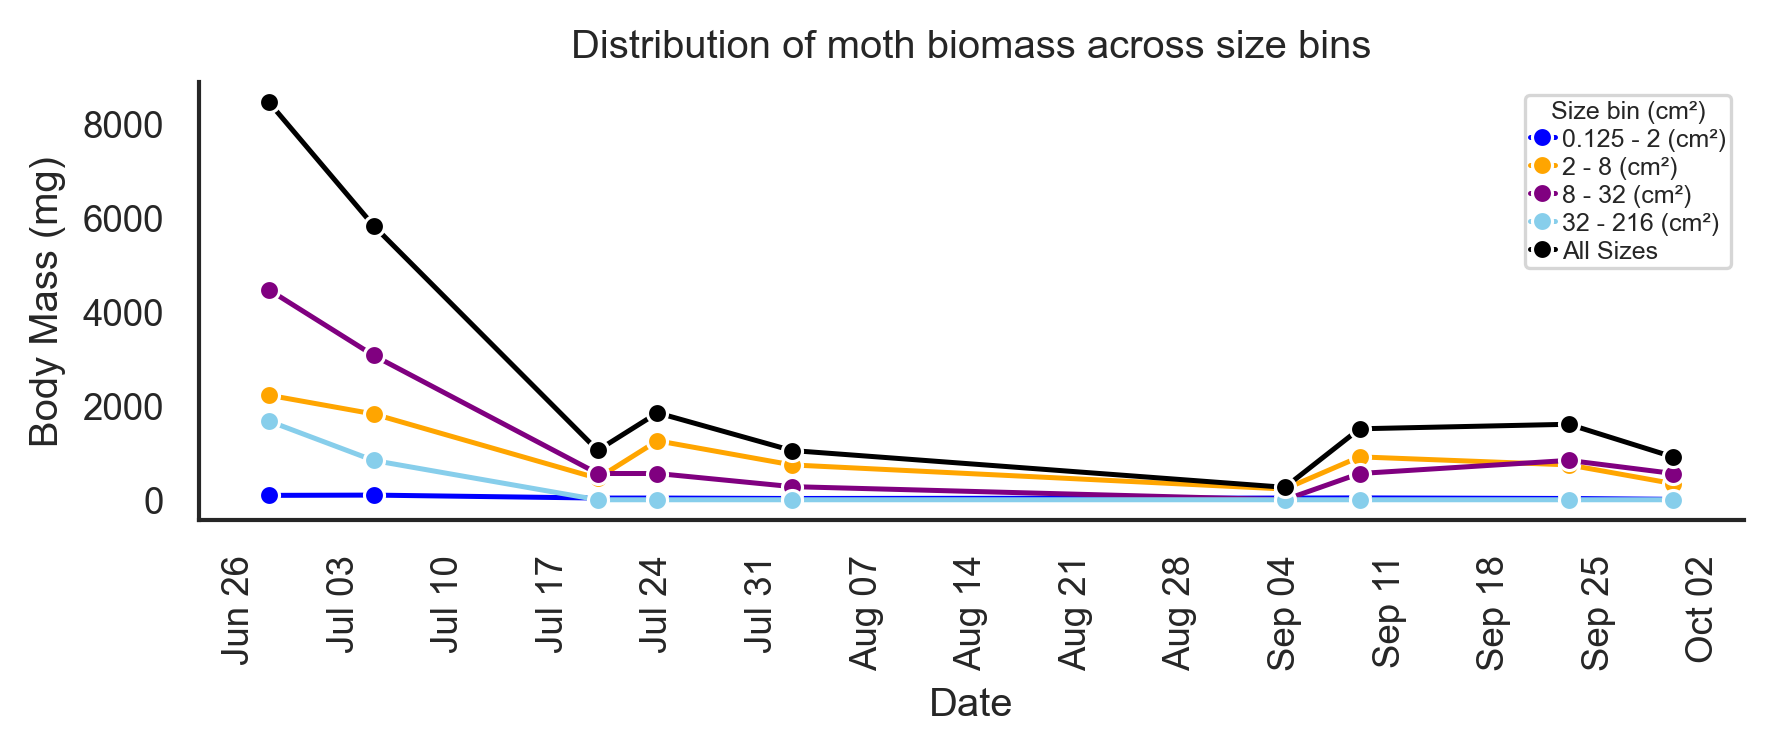

In [104]:
runtrends("2023", "WS6low")